In [1]:
import seaborn as sns
import scanpy as sc
import os
import anndata as ad
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

import os
import pickle


%matplotlib inline
sc.settings.verbosity = 0
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST




In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig1"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# scRNA

In [3]:
# import scanpy as sc
# PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
# adata=sc.read_h5ad(PATH)
# adata.shape

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2.h5ad'
adata=sc.read_h5ad(PATH)
adata.shape

(382782, 36601)

In [5]:
# adata= adata[adata.obs["dataset_id"]!="GSE264508_GSE264508"].copy()
# PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2.h5ad'
# adata.write(PATH)

In [4]:

RENAME = {#"ILC_SELL+CCR7+":   "ILC1_NCR2+P2RX7+", 
          'ILC3 CCL1+PTGDS+': 'ILC3_CCL1+PTGDS+',
       }
adata.obs["tmp"]=adata.obs["lvl4_annotation"].map(RENAME)
adata.obs["lvl4_annotation"]=adata.obs["tmp"].fillna(adata.obs["lvl4_annotation"])

In [7]:
adata.obs["Patient_status"].nunique()

28

In [8]:
adata[adata.obs["Patient_status"]=="Neurofibroma"].obs.Site_status.value_counts()

Site_status
Lesional    1376
Name: count, dtype: int64

In [9]:
adata.obs["Patient_status"].value_counts()

Patient_status
Healthy                          117488
Eczema                            55049
Lyme_disease/Erythema migrans     28319
Psoriasis                         27965
HS                                24576
Lichen planus                     19590
AA                                15836
Bullous pemphigoid                14667
Keloid                            10769
Sarcoidosis                        9267
Granuloma annulare                 8503
SSc                                6670
Non-keloid scar                    5793
DRESS                              4557
Localized Scleroderma (LS)         4532
Prurigo nodularis                  4354
Acne                               3863
Wound                              3844
PSM                                3342
SCLE                               2921
Dupuytren                          2844
Pemphigus                          1834
irAE                               1822
SCC                                1641
Neurofibroma             

In [10]:
file_path = "/nfs/team298/ls34/color_for_adult_skin2.pkl"

with open(file_path, "rb") as f:
    palette_dict = pickle.load(f)         
    
colors = palette_dict

In [11]:
NEW_CELLS = {
    "Th2": "#2A6072",      # Dark Blue (classic, strong contrast)
    "Tfh-like": "#AAA9A9",  # Neon Blue (bright, electric tone)
    "Th17": "#FFB3B3",
     #   "TRM_IL13+": "#7D93C7"
    
}
             
palette_dict = palette_dict | NEW_CELLS
adata.obs['lvl4_annotation'] =adata.obs['lvl4_annotation'] .astype('category') 
adata.uns['lvl4_annotation_colors'] = [palette_dict.get(cat, '#D3D3D3')  for cat in adata.obs['lvl4_annotation'].cat.categories]



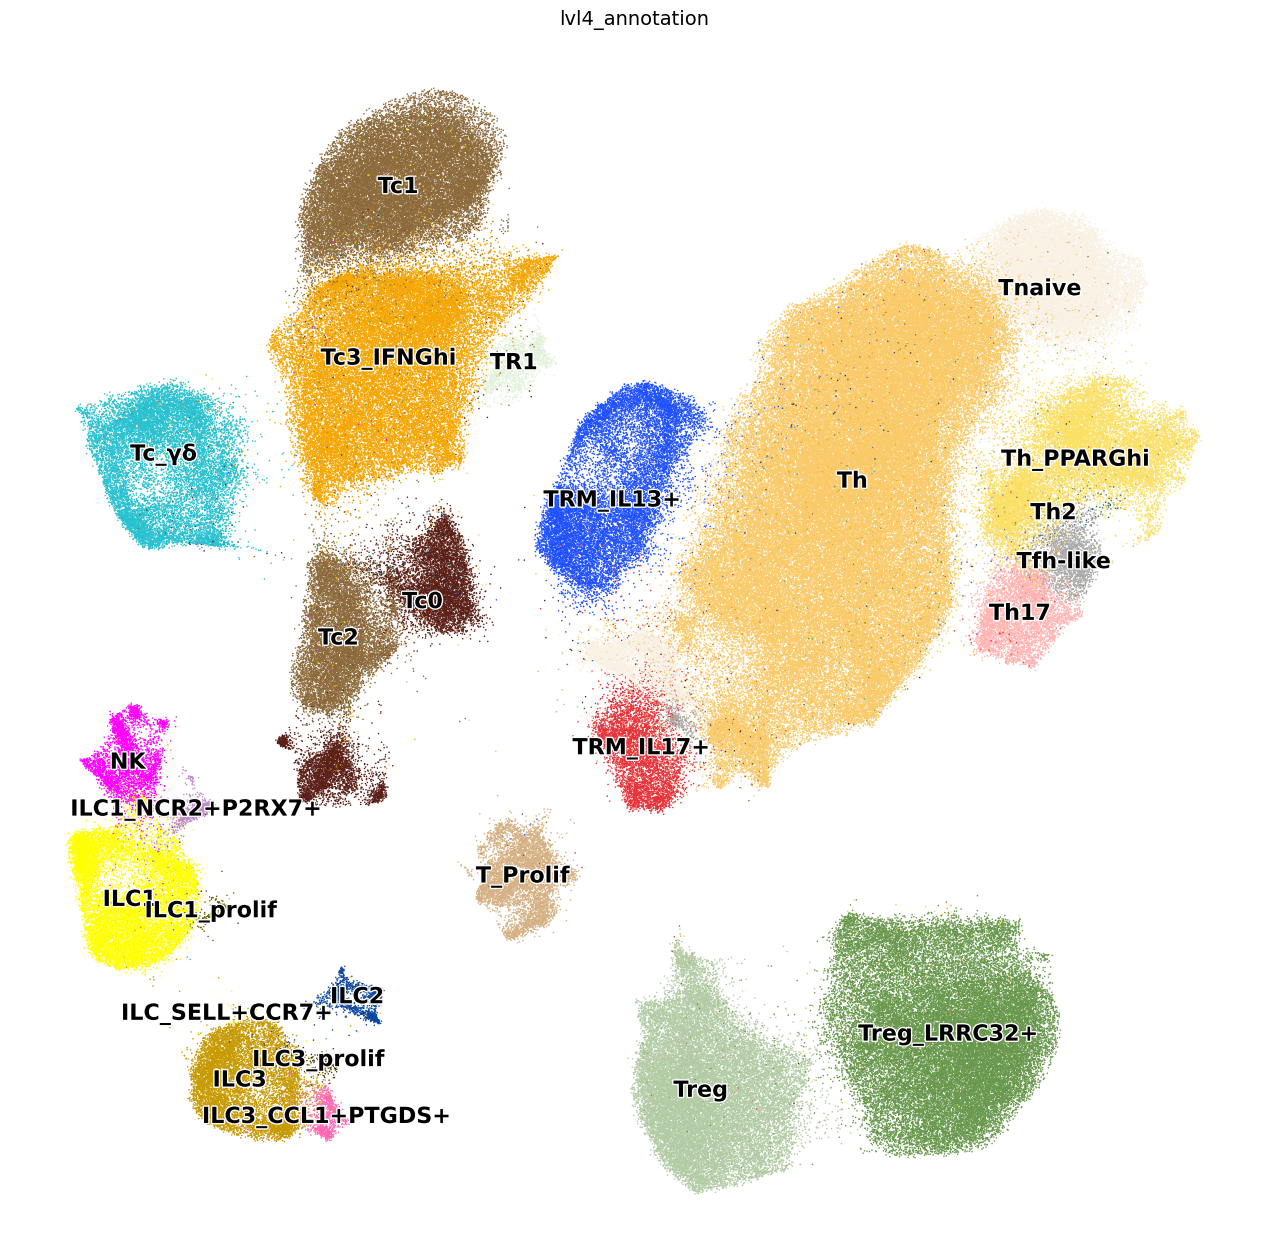

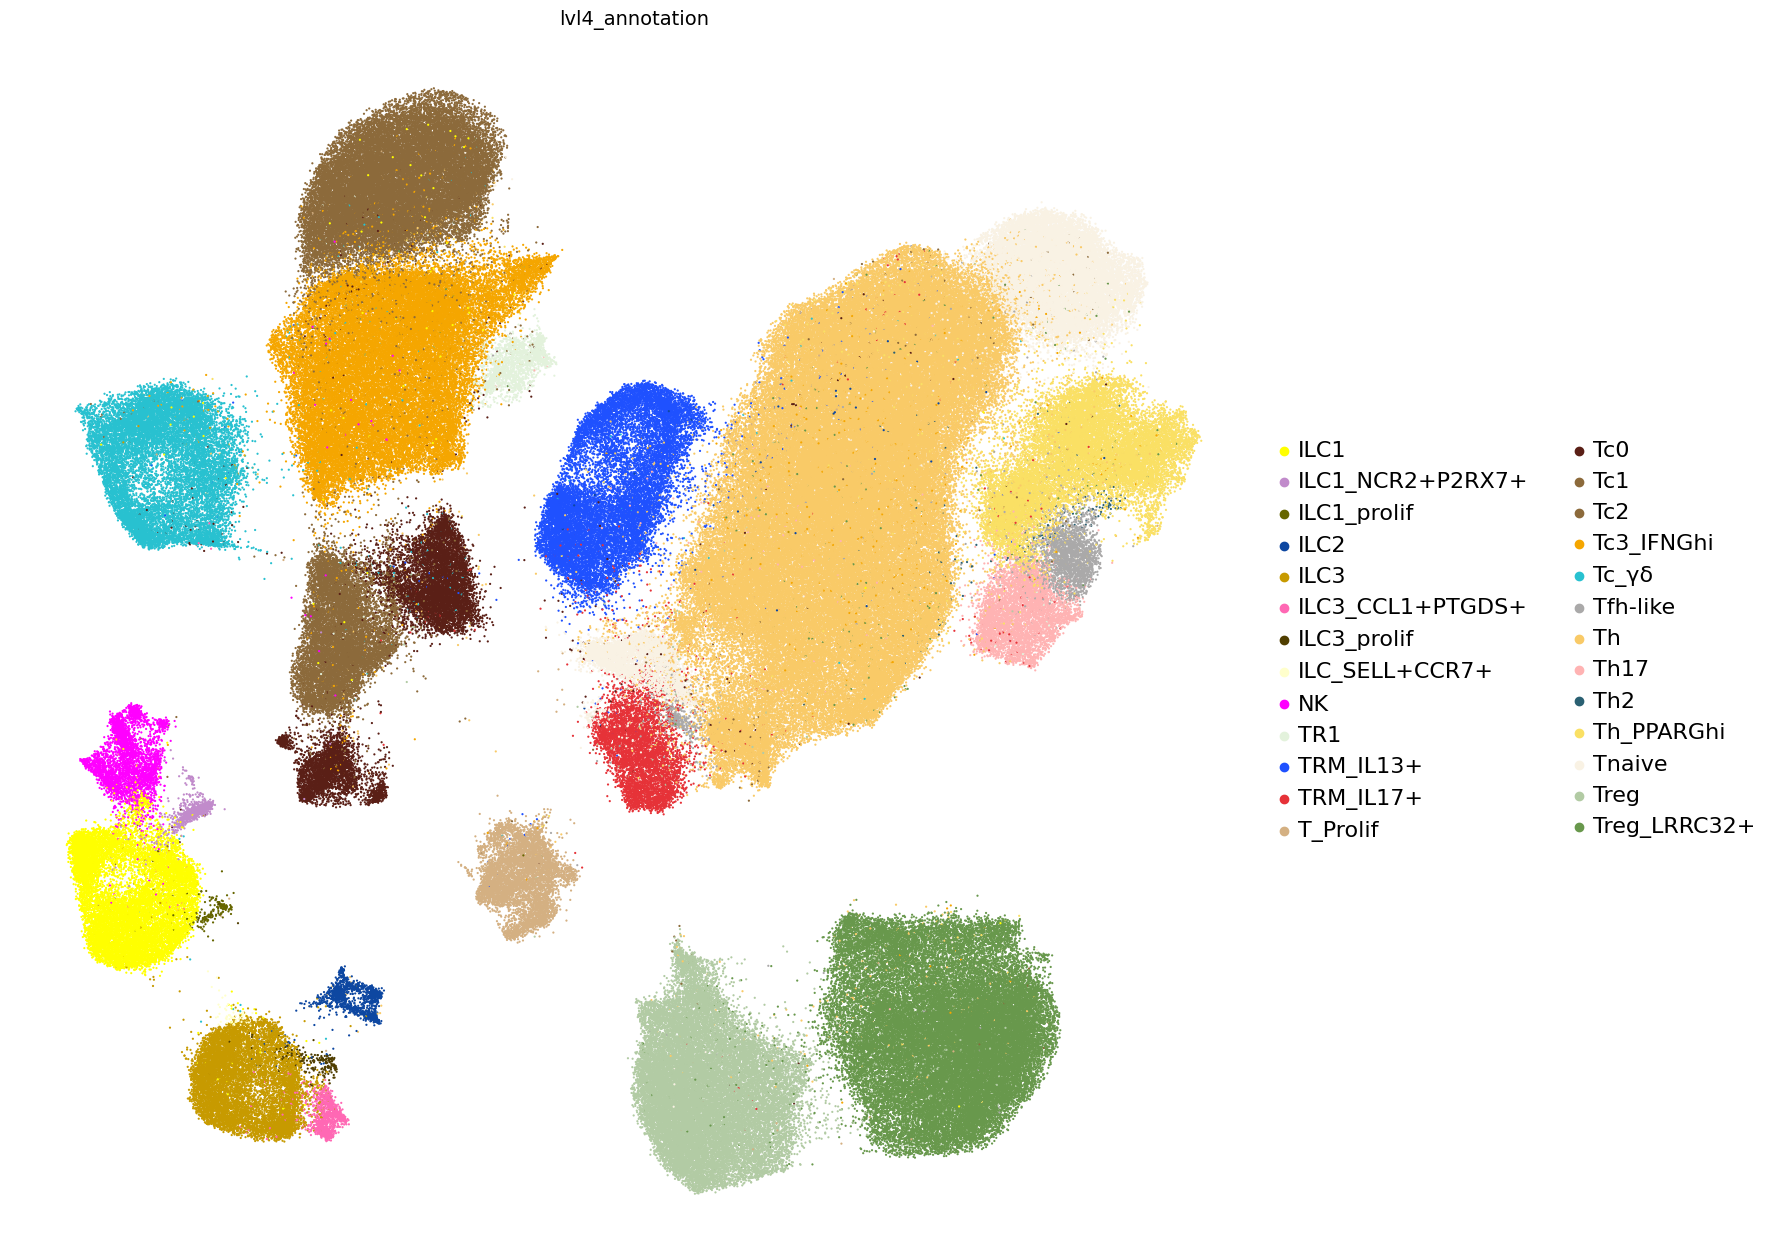

In [12]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(16,16))

sc.pl.umap(
    adata,
    color=[
        'lvl4_annotation',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=16,
        save="6d_umap.pdf"

)

sc.pl.umap(
    adata,
    color=[
        'lvl4_annotation',  
    ],
    #legend_loc="on data",
    s=10, 
    legend_fontoutline=2,
    legend_fontsize=16
)


In [ ]:
# adata=adata[(adata.obs["lvl4_annotation"].str.startswith("ILC"))|
#             (adata.obs["lvl4_annotation"].str.startswith("NK"))
#            ]
# import gc
# gc.collect()
# adata.write('/nfs/team361/ls34/data/adata_ILCskin.h5ad')

In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


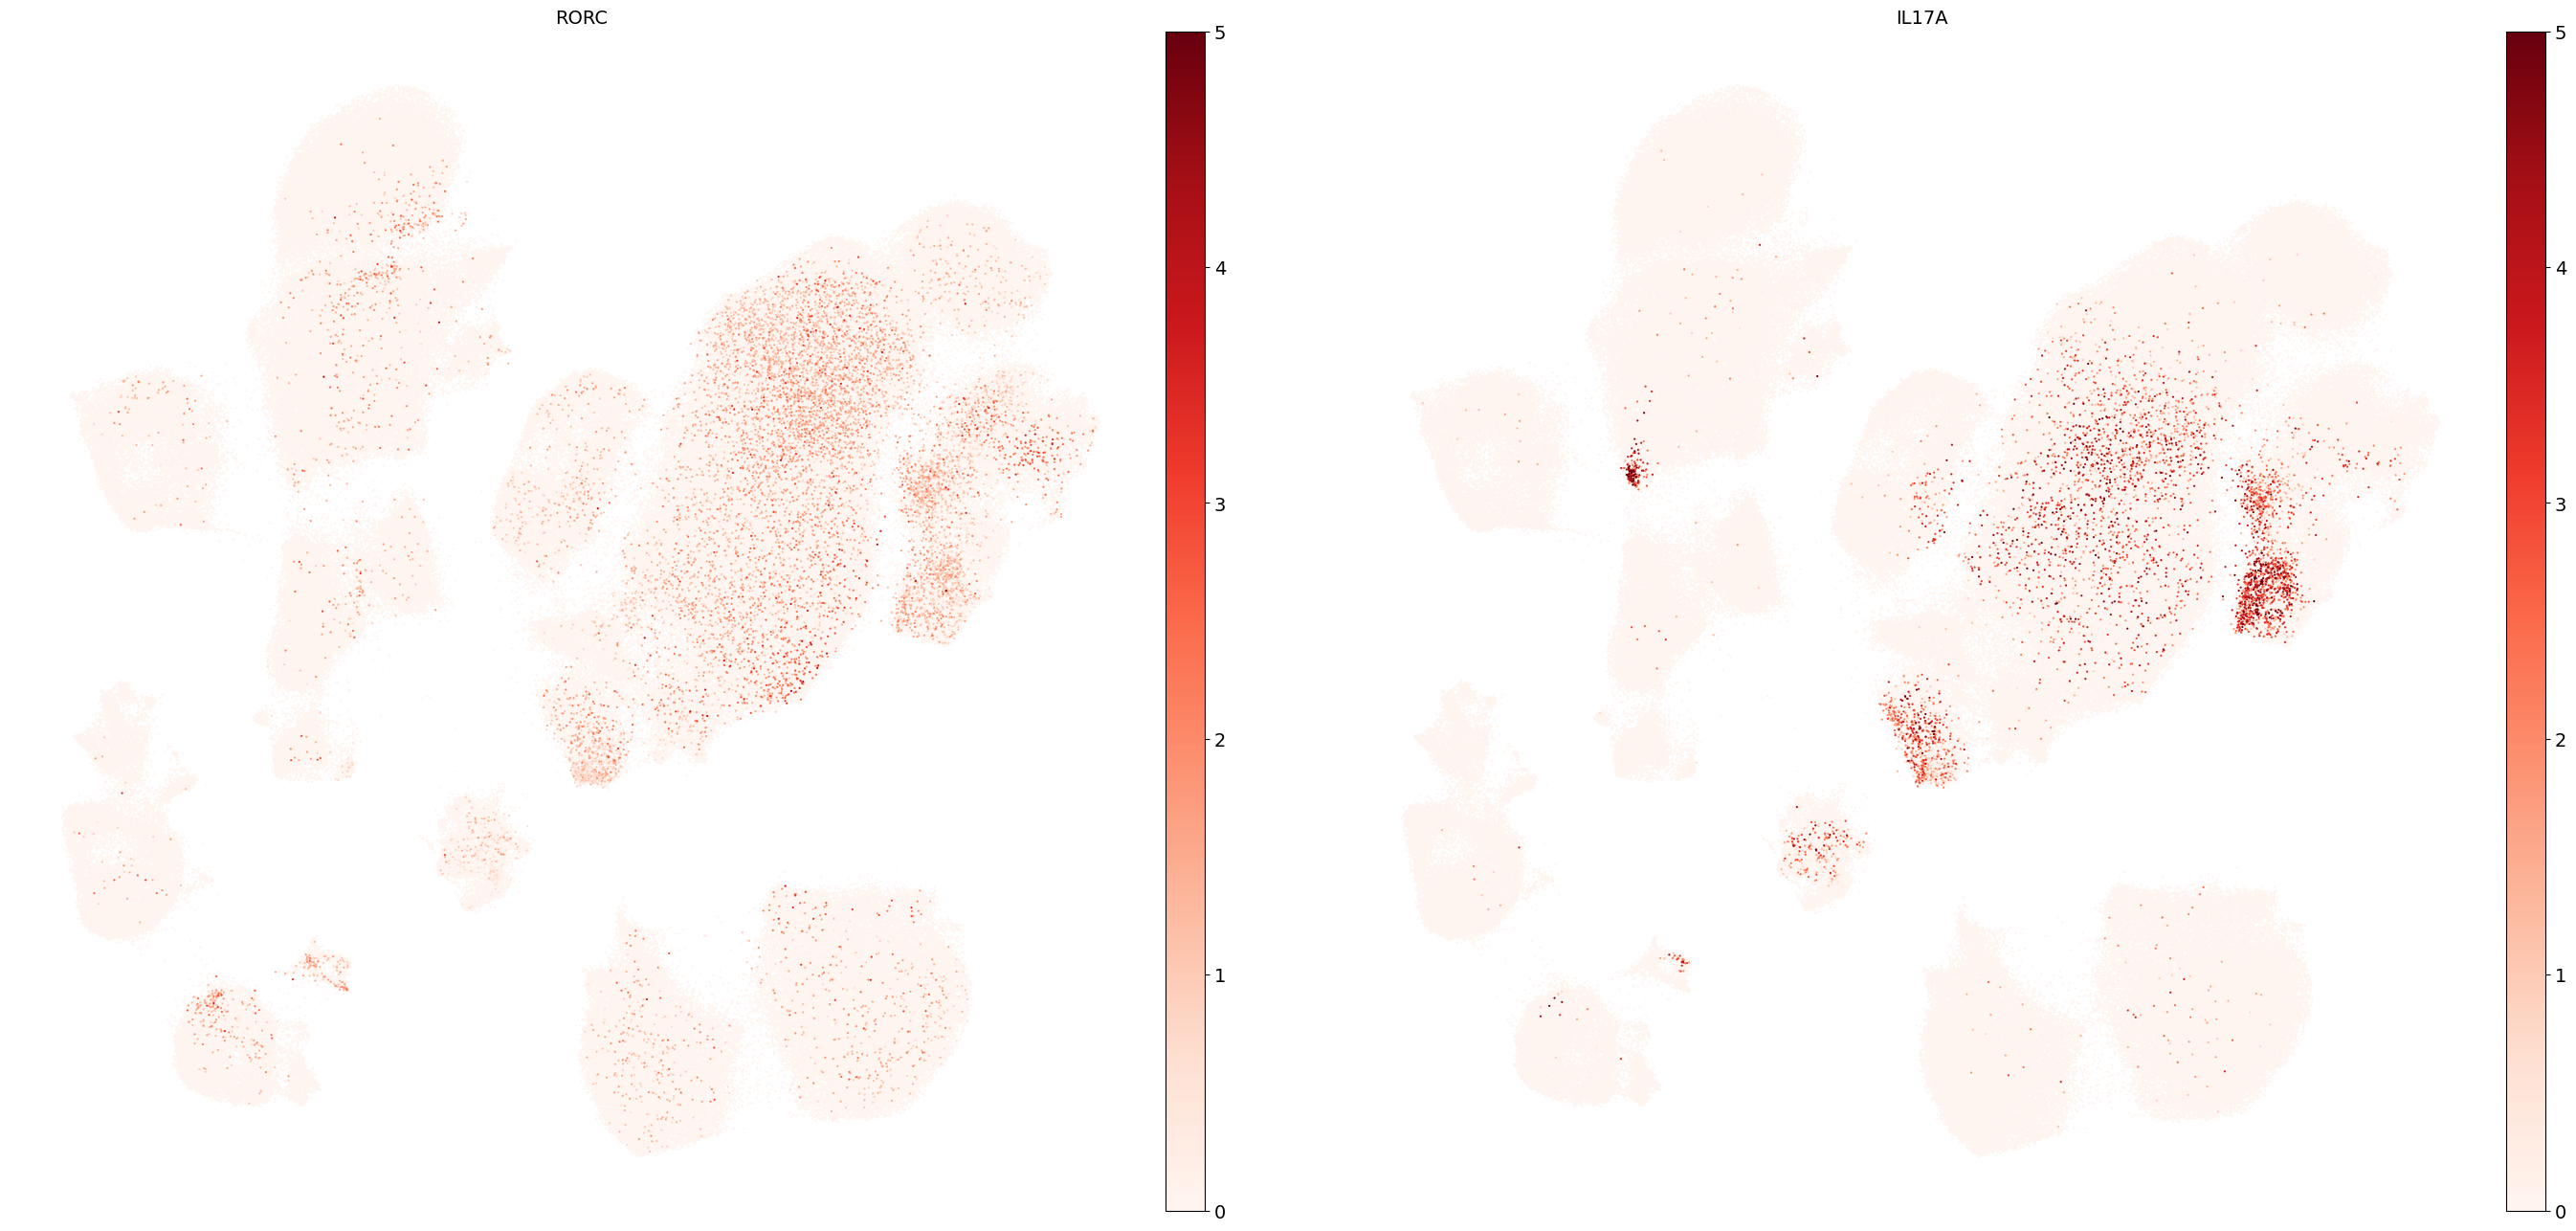

In [14]:
sc.pl.umap(
    adata,
    color=[
        'RORC',"IL17A"  
    ],
    #legend_loc="on data",
    s=10, 
    legend_fontoutline=2,
    legend_fontsize=16,
    cmap="Reds",
    vmax=5,
)


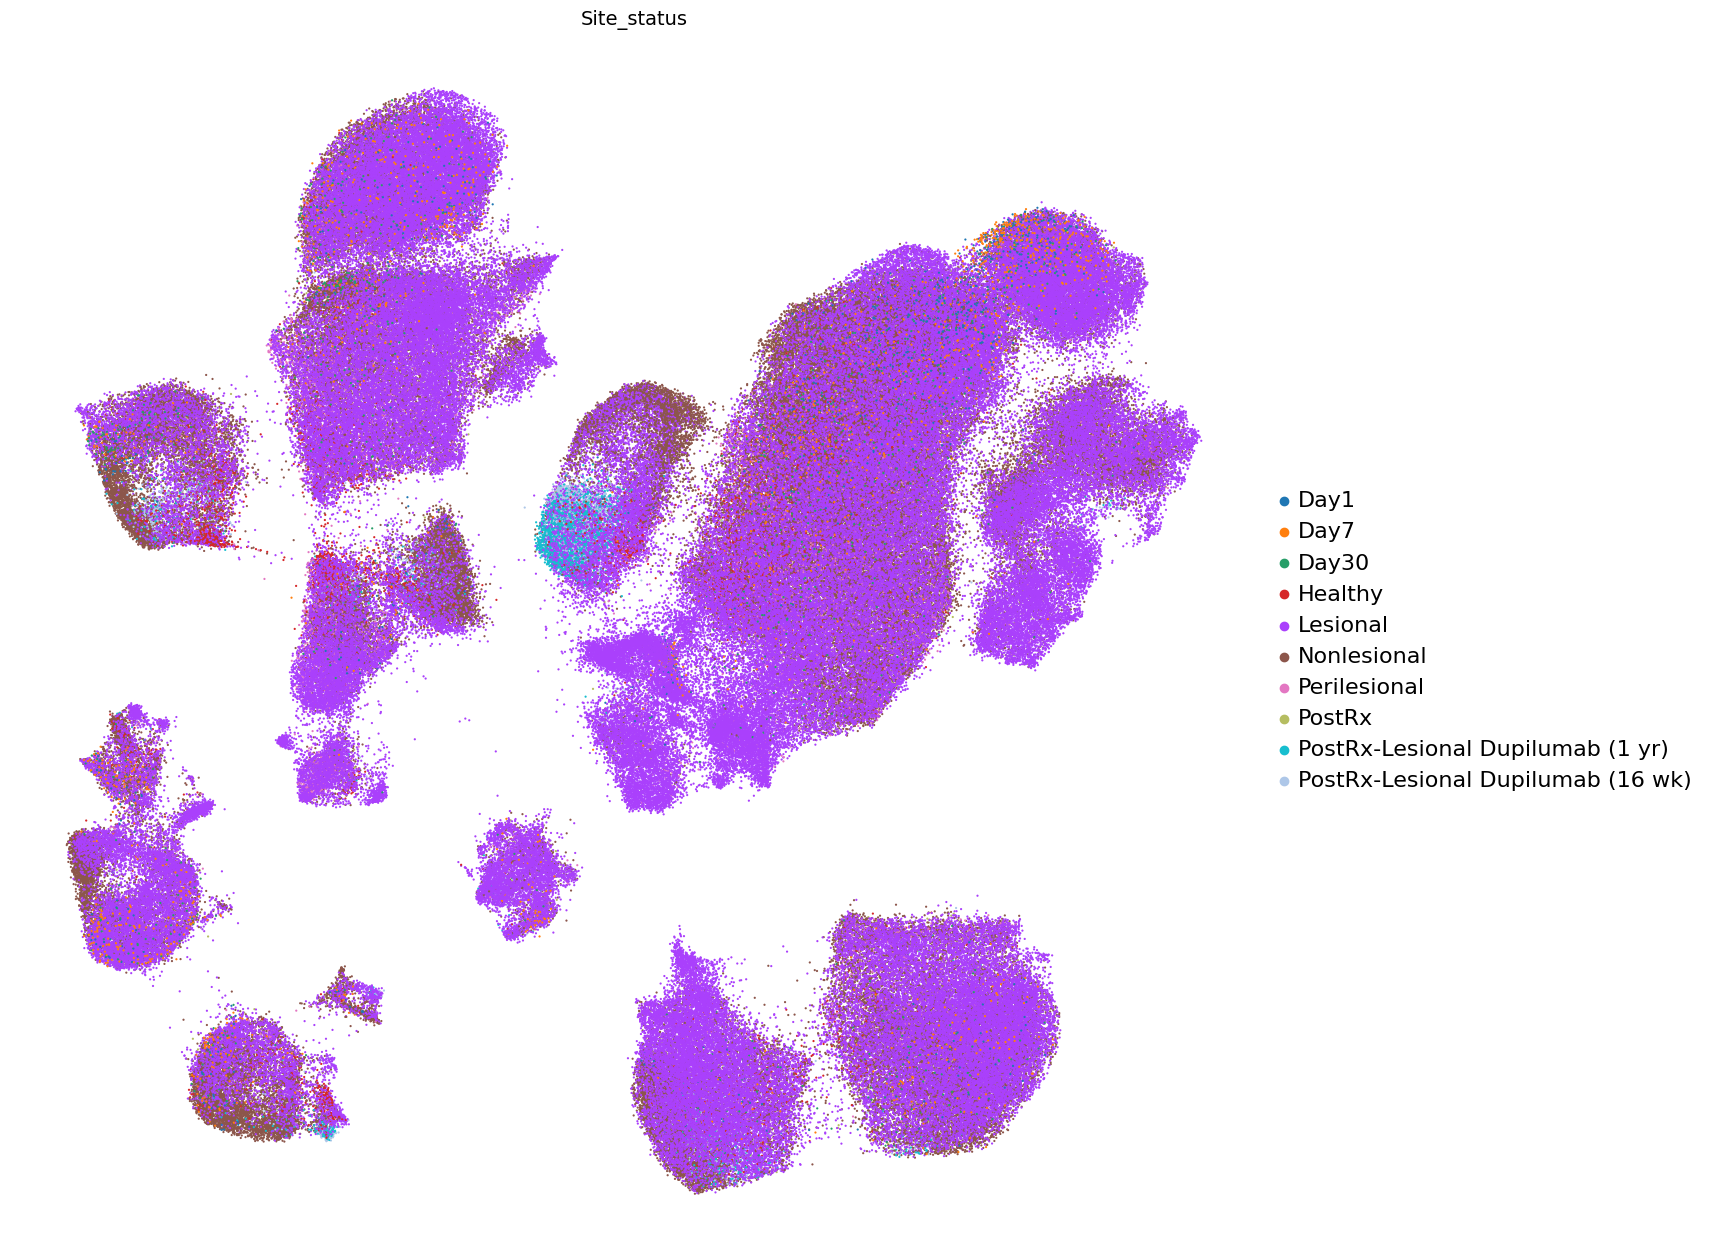

In [15]:
sc.pl.umap(
    adata,
    color=[
        'Site_status',],
    #legend_loc="on data",
    s=10, 
    legend_fontoutline=2,
    legend_fontsize=16,
    cmap="Reds",
    vmax=5,
)


In [16]:
# adata = adata[adata.obs.Site_status=="Lesional"]
# {x:x for x in sorted(adata.obs.Patient_status.unique())}

In [17]:
[x for x in sorted(adata.obs.Patient_status.unique())]

['AA',
 'Acne',
 'Bullous pemphigoid',
 'DLE',
 'DRESS',
 'Dupuytren',
 'Eczema',
 'Eosinophilic fasciitis',
 'Granuloma annulare',
 'HS',
 'Healthy',
 'Keloid',
 'Lichen planus',
 'Localized Scleroderma (LS)',
 'Lyme_disease/Erythema migrans',
 'Neurofibroma',
 'Non-keloid scar',
 'PSM',
 'Pemphigus',
 'Prurigo nodularis',
 'Psoriasis',
 'SCC',
 'SCLE',
 'SSc',
 'Sarcoidosis',
 'Vitiligo',
 'Wound',
 'irAE']

In [18]:
# import pickle

# md = adata.obs["lvl4_annotation"].to_dict()

# outpath = "/nfs/team298/ls34/tcellatlas_labels.pkl"

# with open(outpath, "wb") as f:
#     pickle.dump(md, f, protocol=pickle.HIGHEST_PROTOCOL)

# print("Saved to:", outpath)

# tfh like (supp 13d/e)

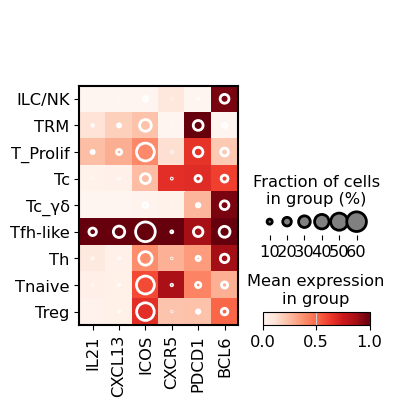

In [19]:
TFH_GENES =['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', 
           ]

dp =sc.pl.DotPlot(adata, 
              TFH_GENES,
              groupby="tfh_plot",
                 standard_scale="var",
            #ot_max=.7,
                      vmax=1,
           #categories_order = ORDER, #[x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="T_scrna.pdf",
                          # colorbar_title="Mean expression\n(minmax norm.)"

             ) 

dp =  dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
               dot_max=.6)
          
dp.savefig("fig6/tfh_dotplot.pdf", dpi=300)       
    

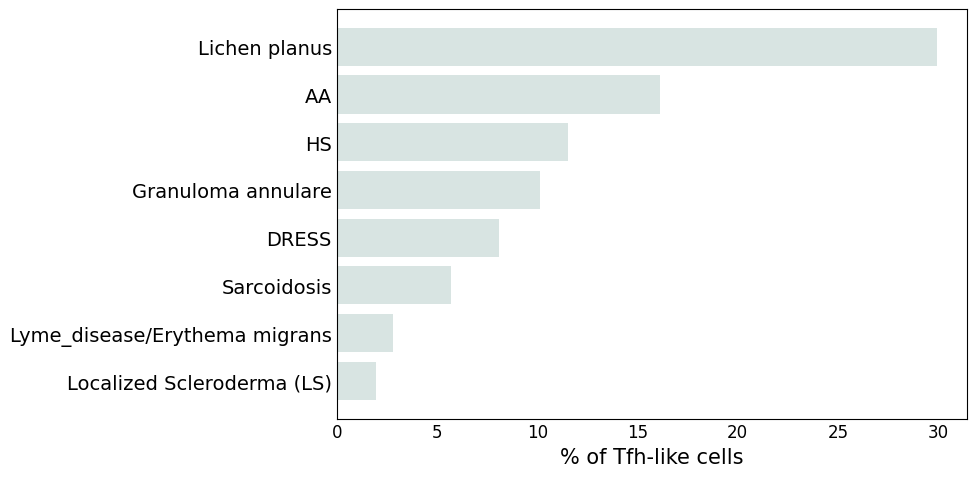

In [20]:
adata=adata[adata.obs["Patient_status2"]!="Nonlesional"].copy()
mask    = adata.obs["lvl4_annotation"] == "Tfh-like"
tfh_obs = adata.obs[mask]

disease_pct = (
    tfh_obs["Patient_status2"]
    .value_counts(normalize=True)
    .mul(100)
    .nlargest(8)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))   #

ax.barh(
    disease_pct.index,
    disease_pct.values,
    color="#d8e4e2"
)

ax.set_xlabel("% of Tfh-like cells", fontsize=15)  # larger x-label font
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=12, length=0)
ax.tick_params(axis="y", length=0)
ax.grid(False)
#_GENE

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)

plt.tight_layout()


fig.savefig("fig6/6d_Tfh_contributors.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Fig 4f (TRMs)

In [21]:
adata_iii = adata[adata.obs["Site_status"] == "Lesional"].copy()

mask_13 = adata_iii.obs["lvl4_annotation"].str.startswith("TRM_IL13")
mask_17 = adata_iii.obs["lvl4_annotation"].str.startswith("TRM_IL17")


ds_col = "Patient_status"

tmp = pd.DataFrame({
    ds_col:         adata_iii.obs[ds_col].values,
    "TRM_IL13+":    mask_13.values.astype(int),
    "TRM_IL17+":    mask_17.values.astype(int)
})

counts   = tmp.groupby(ds_col)[["TRM_IL13+", "TRM_IL17+"]].sum()
totals   = tmp.groupby(ds_col).size()
props    = counts.div(totals, axis=0)


TOP_N=8

props_sorted = (
    props
    .nlargest(TOP_N, "TRM_IL13+")
    .sort_values(by=["TRM_IL13+", "TRM_IL17+"], ascending=[True, True])
)

# totals_top8 = totals.loc[props_sorted.index]

# def first_colour_starting_with(prefix, palette, default):
#     for k, v in palette.items():
#         if k.startswith(prefix):
#             return v
#     return default

# trm_cols   = ["TRM_IL13+", "TRM_IL17+"]
# other_cols = [c for c in props.columns if c not in trm_cols]
# plot_cols  = trm_cols + other_cols

# palette = [
#     "#FFFFFF" if c == "Other"
#     else first_colour_starting_with(c, colors, "#D3D3D3")
#     for c in plot_cols
# ]



# sns.set_theme(style="white")
# fig, ax = plt.subplots(figsize=(6, 8))

# left = np.zeros(len(props_sorted))
# for idx, c in enumerate(plot_cols):
#     ax.barh(
#         props_sorted.index,
#         props_sorted[c],
#         left=left,
#         color=palette[idx],
#         edgecolor="none",
#         linewidth=0,
#         label=None if c == "Other" else c
#     )
#     left += props_sorted[c]



# ax.set_xlabel(
#     "% of T cells in disease",
#     fontsize=16,
#     loc="left"             # ← shift label to the left
# )


# ax.xaxis.set_label_coords(-0.02, -0.07)   # x, y in axes fraction

# ax.set_xlim(0, 0.25)
# ax.set_xticks([0, 0.1, 0.2])
# ax.set_xticklabels([f"{p:.0%}" for p in [0, 0.1, 0.2]], fontsize=18)
# ax.tick_params(axis="x", which="major", length=6, width=1.2, labelsize=18)

# totals_ILCs = counts.sum(axis=1)   # total ILCs per disease
# totals_top10 = totals_ILCs.loc[props_sorted.index]

# yticklabels = [
#     f"{d}_n={n:,}" if n >= 10_000 else f"{d}_n={n}"
#     for d, n in totals_top8.items()
# ]
# ax.set_yticklabels(
#     [f"{d}_n={totals_top10[d]:,}" for d in props_sorted.index],
#     fontsize=14
# )
# ax.set_ylabel("")

# for spine in ["top", "right", "left", "bottom"]:
#     ax.spines[spine].set_visible(True)

# handles, labels = ax.get_legend_handles_labels()
# ax.legend(
#     handles, labels,
#     bbox_to_anchor=(.4, .98),
#     loc="lower center",
#     ncol=1,
#     frameon=False,
#     fontsize=18
# )

# plt.tight_layout()
# plt.savefig(
#     "figures/fig3e_TRM_bypatientstatus_topbars_fixedxlabel2.pdf",
#     dpi=300, bbox_inches="tight"
# )
# plt.show()

/tmp/ipykernel_1015829/1913377444.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts   = tmp.groupby(ds_col)[["TRM_IL13+", "TRM_IL17+"]].sum()
/tmp/ipykernel_1015829/1913377444.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals   = tmp.groupby(ds_col).size()


/tmp/ipykernel_1015829/594418620.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts   = tmp.groupby(ds_col)[ILC_TYPES].sum()
/tmp/ipykernel_1015829/594418620.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals   = tmp.groupby(ds_col).size()
/tmp/ipykernel_1015829/594418620.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels, fontsize=24)


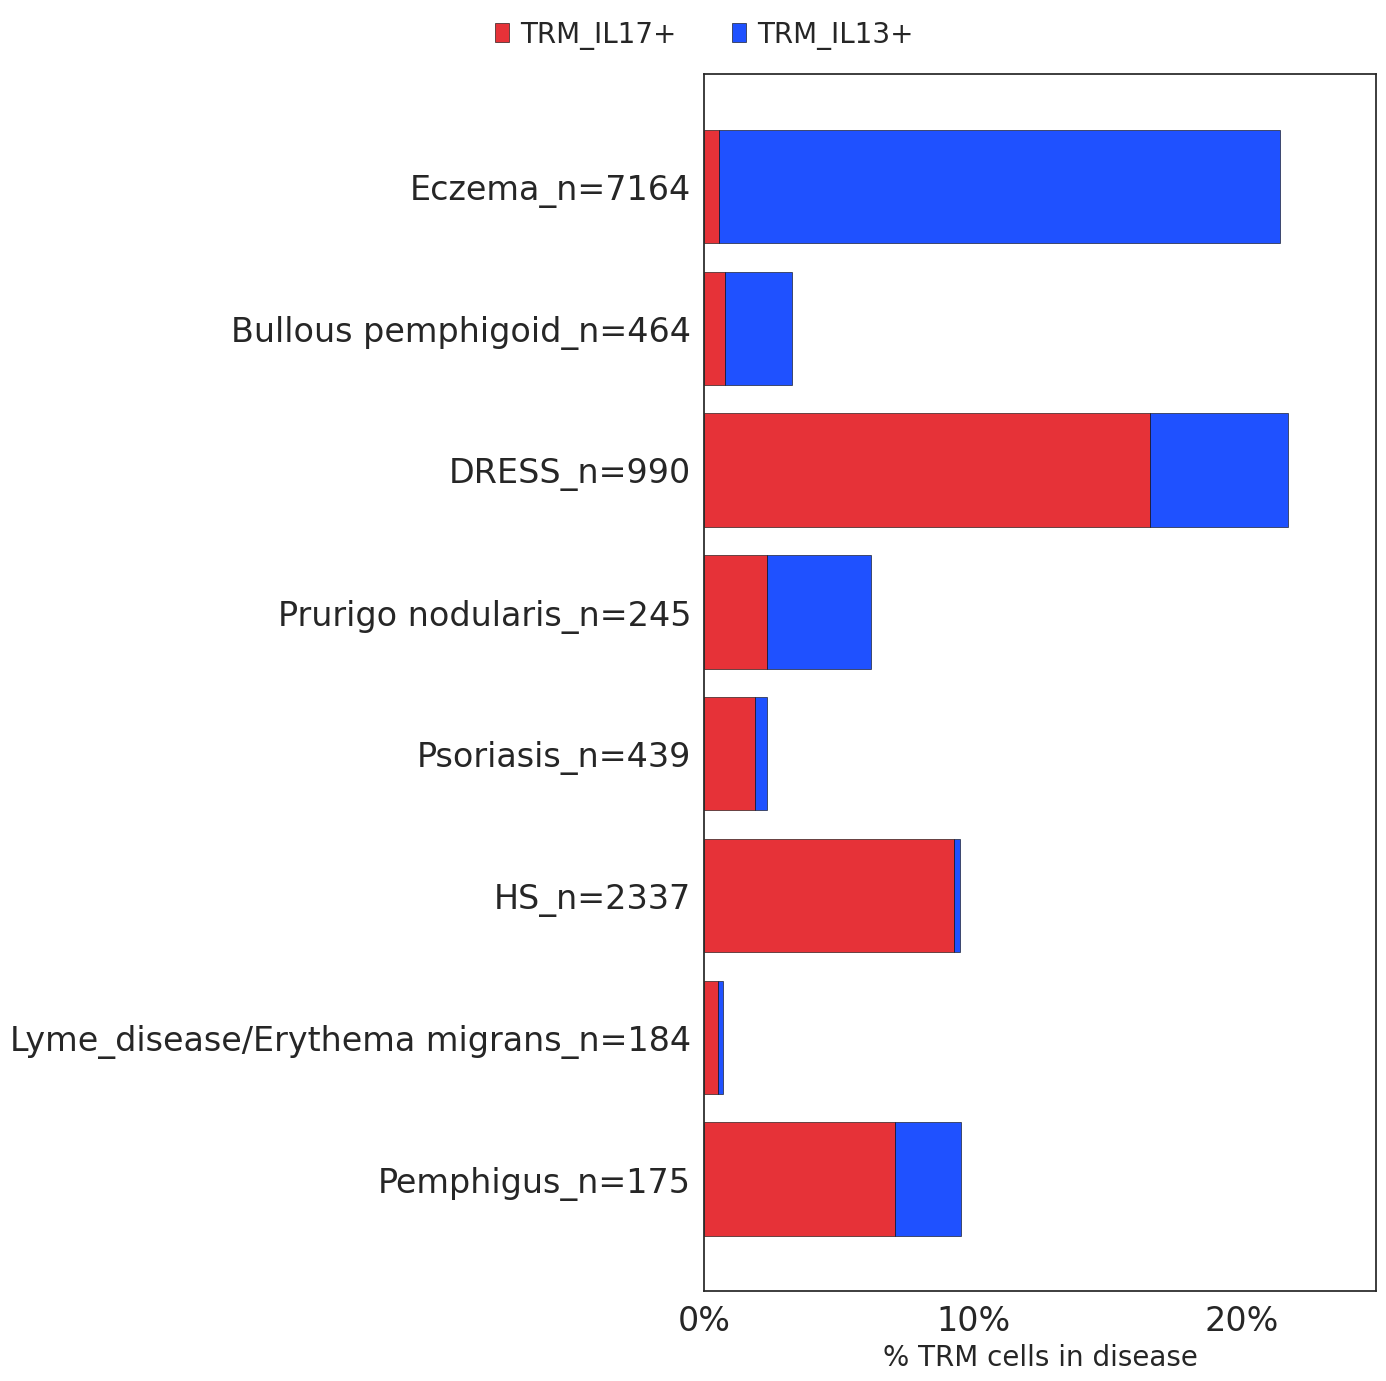

In [22]:
TOP_N=8

#adata_iii = adata[adata.obs["Site_status"] == "Lesional"]

ILC_TYPES = [
    "TRM_IL17+",  "TRM_IL13+", 
]

obs_labels = adata_iii.obs["lvl4_annotation"]
masks = {ct: obs_labels.str.startswith(ct) for ct in ILC_TYPES}

ds_col = "Patient_status"

df_dict = {ds_col: adata_iii.obs[ds_col].values}
for ct in ILC_TYPES:
    df_dict[ct] = masks[ct].values.astype(int)

tmp      = pd.DataFrame(df_dict)
counts   = tmp.groupby(ds_col)[ILC_TYPES].sum()
totals   = tmp.groupby(ds_col).size()
props    = counts.div(totals, axis=0)

top8_diseases = (
    counts
    .nlargest(TOP_N, "TRM_IL13+")
    .index
)

#totals_top8  = totals.loc[props_sorted.index]
props_sorted = props.loc[top8_diseases, ILC_TYPES]

props_sorted = props_sorted.loc[
    counts.loc[top8_diseases].sort_values("TRM_IL13+", ascending=True).index
]

def lookup(name, palette, default="#D3D3D3"):
    for k, v in palette.items():
        if k.startswith(name):
            return v
    return default

palette = [lookup(ct, colors) for ct in ILC_TYPES]

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 14))

left = np.zeros(len(props_sorted))
for idx, ct in enumerate(ILC_TYPES):
    ax.barh(
        props_sorted.index,
        props_sorted[ct],
        left=left,
        color=palette[idx],
        edgecolor="black", linewidth=0.4,
        label=ct
    )
    left += props_sorted[ct]

ax.set_xlabel("% TRM cells in disease", fontsize=20)
ax.set_ylabel("")
ax.set_xlim(0, 0.25)
ax.set_xticks([0, 0.1, 0.2])
ax.set_xticklabels([f"{p:.0%}" for p in [0, 0.1, 0.2]], fontsize=24)
ax.tick_params(axis="x", which="major", length=6, width=1.2, labelsize=24)

totals_ILCs = counts.sum(axis=1)
totals_top8 = totals_ILCs.loc[props_sorted.index]

yticklabels = [
    f"{d}_n={n:,}" if n >= 10_000 else f"{d}_n={n}"
    for d, n in totals_top8.items()
]
yticklabels = [
    f"{d}_n={n:,}" if n >= 10_000 else f"{d}_n={n}"
    for d, n in totals_top8.items()
]
ax.set_yticklabels(yticklabels, fontsize=24)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    bbox_to_anchor=(0.0, 1.0),
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=20
)

plt.tight_layout()
plt.savefig(
    "figures/fig3e_TRM_bypatientstatus_topbars_fixedxlabel2.pdf",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [23]:
T_DICT = {   "Tissue-residency\n markers": ["CD4", "CD8A", "ITGAE",  "CD109", 'ZNF683', "ENTPD1", # "RBPJ"
                                        "ITGAV"
                                       ],
# 'IL22': ['IL22', 'IL13', 'PDLIM4', #'KRT7',
#         # "NBAS", 
#          'CCL1', #"CCL17", 
#          "AREG", "CCR8", "IL9R", #"CCR4", "CCR10"
#         ],
 'T_17': [ 'IL17A', 'IL17F', 'CXCL13', 'IL26', "IL21", 'CCL20', 'CTSH', "IL23R",
         "CCR6","RORC", 'TNFRSF8', "ADAM12", #"IL1R1", #"IL12RB2",
            'LRRN3',         'MYO7A',  "VDR", #"CD38",
       
         ],
         "Other": [    "PTPN13","ITGA1", "IFNG"],
         # "ITGA1hi": ["ITGA1", 
         #             'ZHX2',# 'TRPS1', 'TBC1D22A', 'ABLIM1', 
         #             'BICD1',#'MVB12B', 
         #             'PRR5L', # 'PCNX4', 'EPHA4', 
         #             'ST8SIA1', 
         #             'ZNF407',],
         #"Memory": ["CD69",],
#               'Gamma-delta': ["FXYD2", "TRGC2", 'TRDV1','TRGV4',  "EMP1",
#                              "NSG1", #"LINC02446","CD9", 
#                               "MPZL2", "KLRC2"], #'TRGC2', 
          
          "TRM1" : ["CTSH", "MAPKAPK3", "RTL8C", "KAT5", 
        "SMARCD3", "SV2C", "UBXN6", "PHEX", "ZNF524", "UBQLN4", "EXOSC4", "CAMK1", "NKIRAS2", "ANKRD40",
        "ZNF23", "COPG2", "PARP6", "IL13", "CRMP1", "DUSP12", "MAK16", "RCAN1", "PTGES2", "CCDC22", "TCEANC2", "RYR1",
        "AP1S1", "NME6",  "UMPS",
        "HMOX1", "EGLN3", "ITGB8", "SORD", "RNF135", "CCL20", "COL6A3", "MMAB", "C3orf14", "LRRC1",
        "ZNF71", "PCBP4", "FAM86C1", "DRICH1", "RTKN", 
        
        
        
       ]}


In [24]:
mask_13 = adata_iii.obs["lvl4_annotation"].str.startswith("TRM_IL13")
adata_iiii=adata_iii[mask_13]
adata_iiii.obs["lvl4_annotation"].value_counts()

lvl4_annotation
TRM_IL13+    8104
Name: count, dtype: int64

In [25]:
# sc.pp.normalize_total(adata_iiii, target_sum=1e4)
# sc.pp.log1p(adata_iiii)


In [26]:
T_DICT2 = {   "Tissue-residency\n markers": ["CD4", "CD8A", "ITGAE",  "CD109", 'ZNF683', "ENTPD1", # "RBPJ"
                                        "ITGAV"
                                       ],
'IL22': ['IL22', 'IL13', 'PDLIM4', #'KRT7',
        # "NBAS", 
         'CCL1', #"CCL17", 
         "AREG", "CCR8", "IL9R", #"CCR4", "CCR10"
        ],
 'T_17': [ 'IL17A', 'IL17F', 'CXCL13', 'IL26', "IL21", 'CCL20', 'CTSH', "IL23R",
         "CCR6","RORC", 'TNFRSF8', "ADAM12", #"IL1R1", #"IL12RB2",
            'LRRN3',         'MYO7A',  "VDR", #"CD38",
       
         ],
         "Other": [    "PTPN13","ITGA1", "IFNG"],
         # "ITGA1hi": ["ITGA1", 
         #             'ZHX2',# 'TRPS1', 'TBC1D22A', 'ABLIM1', 
         #             'BICD1',#'MVB12B', 
         #             'PRR5L', # 'PCNX4', 'EPHA4', 
         #             'ST8SIA1', 
         #             'ZNF407',],
         #"Memory": ["CD69",],
#               'Gamma-delta': ["FXYD2", "TRGC2", 'TRDV1','TRGV4',  "EMP1",
#                              "NSG1", #"LINC02446","CD9", 
#                               "MPZL2", "KLRC2"], #'TRGC2', 
          
        #   "TRM1" : ["CTSH", "MAPKAPK3", "RTL8C", "KAT5", 
        # "SMARCD3", "SV2C", "UBXN6", "PHEX", "ZNF524", "UBQLN4", "EXOSC4", "CAMK1", "NKIRAS2", "ANKRD40",
        # "ZNF23", "COPG2", "PARP6", "IL13", "CRMP1", "DUSP12", "MAK16", "RCAN1", "PTGES2", "CCDC22", "TCEANC2", "RYR1",
        # "AP1S1", "NME6",  "UMPS",
        # "HMOX1", "EGLN3", "ITGB8", "SORD", "RNF135", "CCL20", "COL6A3", "MMAB", "C3orf14", "LRRC1",
        # "ZNF71", "PCBP4", "FAM86C1", "DRICH1", "RTKN", 
        
        
        
       }


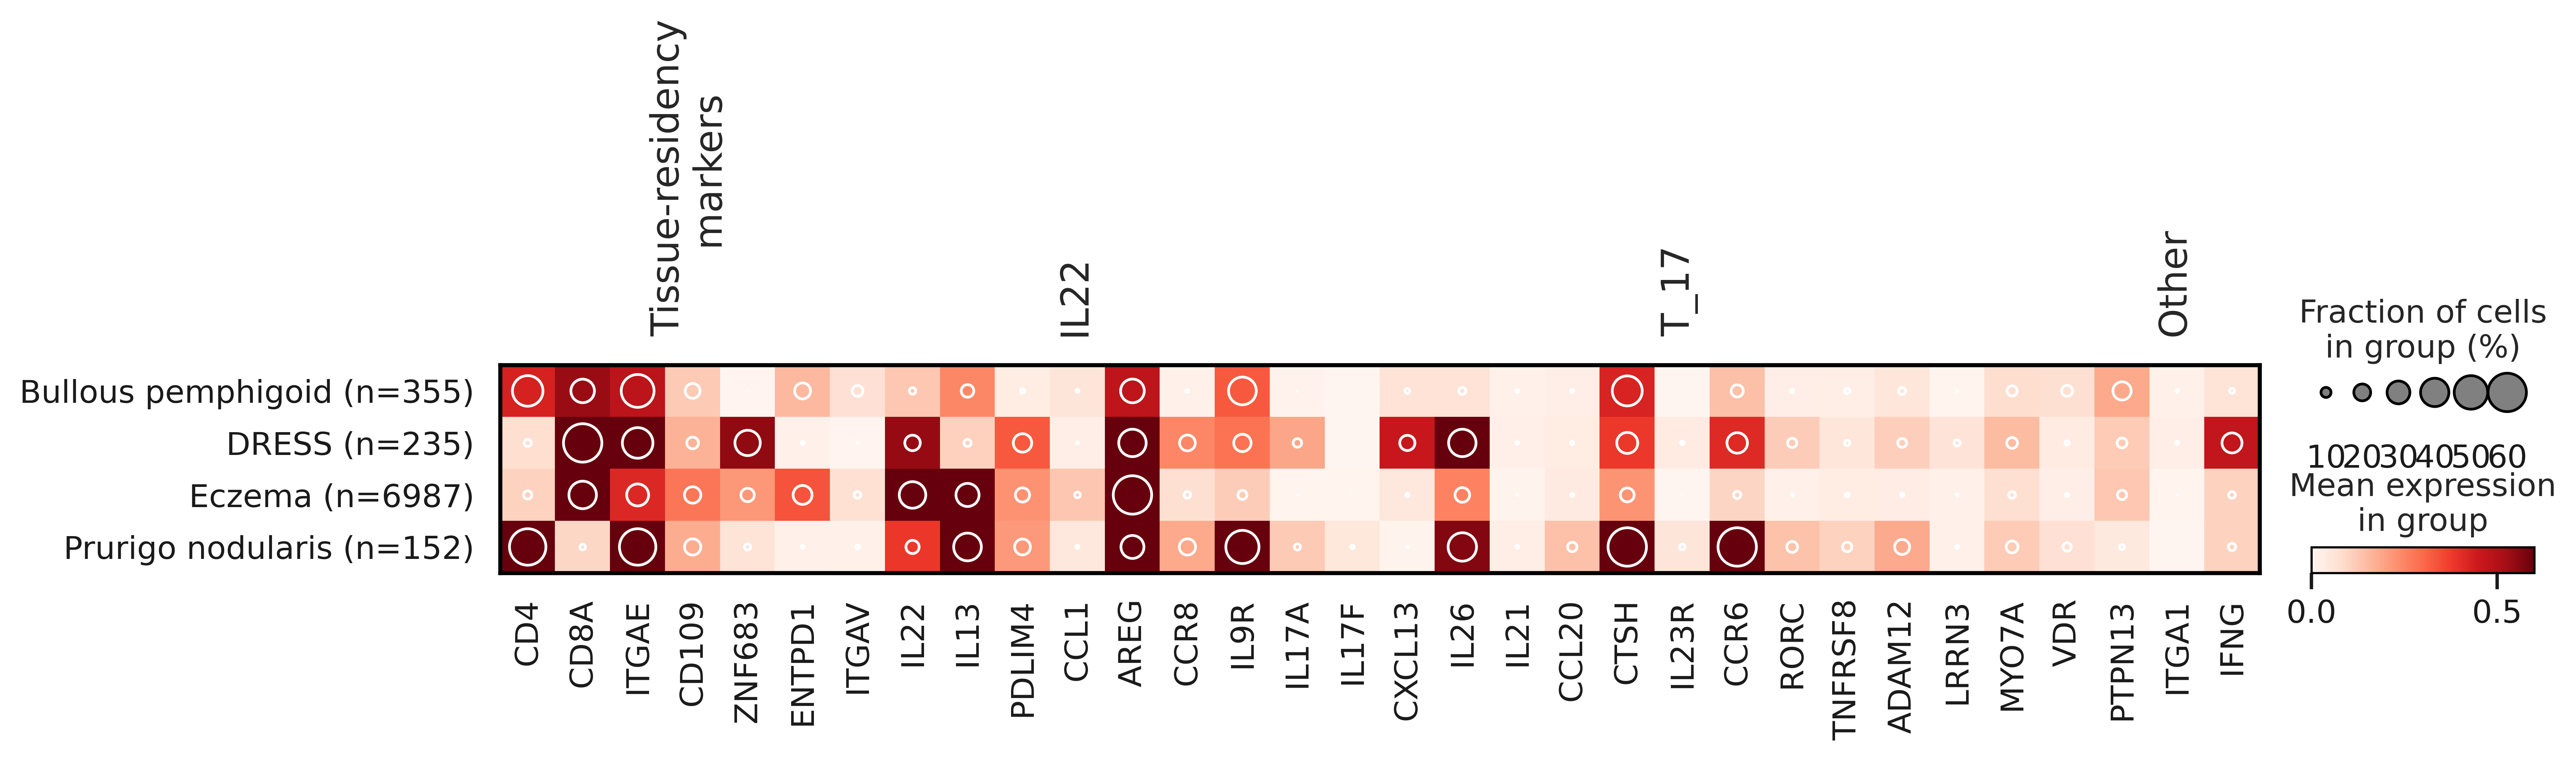

In [27]:
# Step 1: Count the number of cells per Patient_status
T2 = ["Eczema", "Prurigo nodularis", "Bullous pemphigoid", "DRESS"]
adata_iiii=adata_iiii[adata_iiii.obs["Patient_status"].isin(T2)]
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Identify Patient_status values with at least 20 cells
valid_statuses = counts[counts >= 20].index

# Step 3: Filter the AnnData object
adata_iiii = adata_iiii[adata_iiii.obs["Patient_status"].isin(valid_statuses)].copy()
adata_iiii.obs["Patient_status"].value_counts()
# Step 1: Count cells per group
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Build new labels like "PatientA (n=123)"
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}

# Step 3: Add a new column with updated labels
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs["Patient_status"].map(label_map)

# Step 4: Sort by counts descending
sorted_labels = [label_map[g] for g in counts.index]


sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(8,8))


sc.pl.DotPlot(
    adata_iiii,
   remove_markers(T_DICT2),
    #swap_axes=True,
    groupby='Patient_status_labeled',
   vmax=.6,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
   # categories_order=["Treg", "Treg_LRRC32+", "TR1"]
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=.6

          )\
.show()
sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# all ilc

In [28]:
with open('/nfs/team298/ls34/dicts/ilc3_subtypes.pkl', 'rb') as f:
    md = pickle.load(f)
    
adata.obs["tmp"]=adata.obs.index.map(md)
adata.obs["lvl4_annotation2"]=adata.obs["tmp"].fillna(adata.obs["lvl4_annotation2"])

In [29]:


MIN_N = 10


def remove_markers(markers, adata):
    return {
        k: [g for g in v if g in adata.var_names]
        for k, v in markers.items()
    }

# --------------------------
def add_final_with_n(adata, min_n=20):
    vc = adata.obs["Patient_status"].value_counts()
    keep = vc[vc >= min_n].index

    adata.obs["final_filtered"] = (
        adata.obs["Patient_status"]
        .where(adata.obs["Patient_status"].isin(keep))
        .astype("category")
    )

    vc = adata.obs["final_filtered"].value_counts()

    adata.obs["final_with_n"] = (
        adata.obs["final_filtered"]
        .astype(str)
        .map(lambda x: f"{x}_n={vc[x]}" if x != "nan" else None)
        .astype("category")
    )

In [30]:
adata_ilc = adata[(adata.obs["lvl4_annotation"].str.startswith("ILC"))|
                 (adata.obs["lvl4_annotation"].str.startswith("NK"))
                 ].copy()
genes = {"ilc3": [
    "NEB", "IL17A", "RORC", "IL22", "NCR2", "PCDH9", "KIT", "LST1", "CD74",
    "SLC4A10", "SPRY1", "AHR", "CALCRL", "ADRB2", "KLRG1", "MS4A2",
    "ZBTB16", "IL7R", "ID2", "TCF7", "TOX2", "ZBTB16",  # "HLA-DRA1", "HLA-DRB",
    'HLA-DRA',
 'HLA-DRB5',
 'HLA-DRB1',
 'HLA-DQA1',
 'HLA-DQB1',
 'HLA-DQB1-AS1',
 'HLA-DQA2',
 'HLA-DQB2',
 'HLA-DOB',
 'HLA-DMB',
 'HLA-DMA',
 'HLA-DOA',
 'HLA-DPA1',
 'HLA-DPB1', "CCR6", "CCR8", "CCR4", "CIITA",  "IL7R"
    
]}


#add_final_with_n(adata_ilc, MIN_N)


# sc.pl.dotplot(
#     adata_ilc,
#     remove_markers(genes, adata_ilc),
#     groupby="lvl4_annotation",
#     dendrogram=False,
#     vmax=1,
#    # standard_scale="var",
    
#    #categories_order=ORDER,
#   #               #   save=f"{POPULATION}_d_original_dotplot_scrna.pdf"

# ) 
# sc.pl.dotplot(
#     adata_ilc,
#     remove_markers(genes, adata_ilc),
#     groupby="lvl4_annotation",
#     dendrogram=False,
#     vmax=1,
#    # standard_scale="var",
    
#    #categories_order=ORDER,
#   #               #   save=f"{POPULATION}_d_original_dotplot_scrna.pdf"

# ) 

In [31]:
adata_ilc.shape

(18996, 36601)

In [32]:
# sc.pp.normalize_total(adata_ilc, target_sum=1e4)
# sc.pp.log1p(adata_ilc)


In [33]:
# md = adata_i.obs["provisional2"].to_dict()
# adata.obs["tmp"]=adata.obs.index.map(md)
# adata.obs["lvl4_annotation2"]=adata.obs["tmp"].fillna(adata.obs["lvl4_annotation2"])

In [34]:
# import pickle

# with open('/nfs/team298/ls34/dicts/ilc3_subtypes.pkl', 'wb') as f:
#     pickle.dump(md, f)

In [35]:
adata.obs["lvl4_annotation2"].value_counts()

lvl4_annotation2
Other                  246298
ILC1                     8896
ILC3                     3556
NK                       2210
ILC2                      990
ILC1_NCR2+P2RX7+          934
ILC3_CCL1+PTGDS+          842
ILC3_TOX2+_earliest       772
ILC3_Early                384
ILC3_Prolif               188
ILC1_prolif               133
ILC_SELL+CCR7+             91
Name: count, dtype: int64

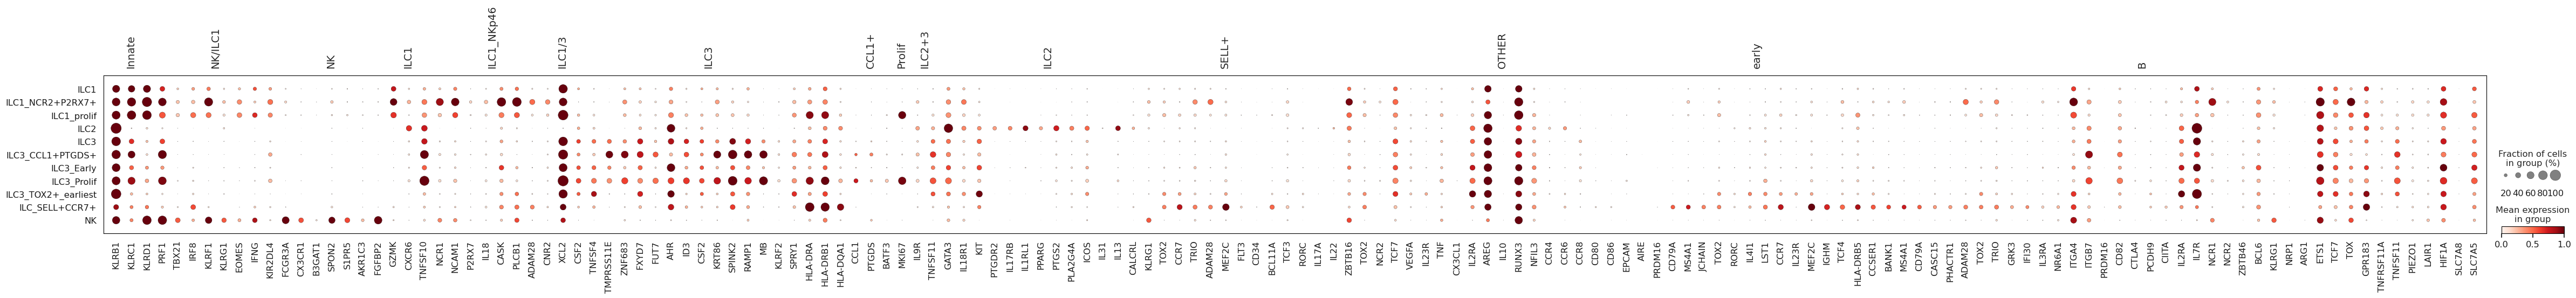

In [36]:
# ALLT2 = {'Innate': [
#   'KLRB1',
#   'KLRC1',"KLRD1",
#   'TYROBP',
#   'FCER1G',
# ],
#          "NK/ILC1": ['PRF1','KLRD1','TBX21','IRF8',  'KLRF1',
#   'KLRG1','KLRC2',
#   'KLRC3', 'CEBPD',"FGR", "EOMES", "IFNG", 'SLA2', 'KIR2DL4', 'SH2D1B', 'SLFN13', 'TMIGD2'],
#  'NK': [  'FCGR3A',
 
#   'CX3CR1',
#   'CCL4L2',
#   'PRSS23', 'B3GAT1',
#        'SPON2',
#   'S1PR5',
#   'AKR1C3',
#          'FGFBP2',



#   'S100B'],

#          "ILC1": [ "ADGRG3", 'GZMK', 'OASL', 'CXCR6' , "TNFSF10" ],
#          "ILC1_NKp46":  [ 'NCR1', 'NCAM1',  'P2RX7',   'ZNF407', "IL18",'ZBTB20', 'CASK',# "ITGA1",
#                        'PLCB1', 'ADAM28',  'CNR2', "KLRG1",
#                         ],
#  'ILC1/3': ['XCL1', 'XCL2', ],
#           'ILC3': ['ID3','CSF2', 'KRT86',
#  # 'ZBTB46',
#   'TNFSF4',
#   'SPINK2',
#   'RAMP1',
#   'MB',
#   'KLRF2',
#   'TMPRSS11E', "ZNF683",
#                   "FXYD7", "FUT7", "AHR", "SPRY1",
#                    "HLA-DMA",'HLA-DRA','HLA-DQA1','CD74' ,"ID2"
#                   ],
#            'PTGDS': [  'PTGDS', 'PDLIM4', 'CCL1',
#                    # "MYO1E", "PTGER3",
#                      'KCNQ2', #'CDCP1', 'LILRA2','HHEX', 
#                      'CCR8'
#                     ],
#     "Prolif": ["MKI67"],

#  'ILC2+3': ['IL9R', 'TNFSF11'],
#  'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
#           'CRLF2',
#   'IL17RB',
#   'IL1RL1',

#   'PPARG',
#   'PTGS2',
#   'PLA2G4A',
#   #'IL4',

#   'ICOS',
#   'NRROS',     'IL31',
# 'IL22', 'IL13',  
#           #'AREG', 'CCR8',
#           'CALCRL',
         
         
#          # "MAF", "MCAM", "NTRK2", "IL26","PLN",
#           "KCNMA1",
#          ],
#         }
ALLT2 = {'Innate': ['KLRB1', 'KLRC1', 'KLRD1'],
 'NK/ILC1': ['PRF1',
 # 'KLRD1',
  'TBX21',
  'IRF8',
  'KLRF1',
  'KLRG1',
  #'KLRC2',
  #'FGR',
  'EOMES',
  'IFNG',
  'KIR2DL4',
  #'SH2D1B',
  #'TMIGD2'
            ],
 'NK': ['FCGR3A', 'CX3CR1', 'B3GAT1', 'SPON2', 'S1PR5', 'AKR1C3', 'FGFBP2'],
 'ILC1': ['GZMK', 'CXCR6', 'TNFSF10'],
 'ILC1_NKp46': ['NCR1',
  'NCAM1',
  'P2RX7',
  'IL18',
  'CASK',
  'PLCB1',
  'ADAM28',
  'CNR2',
        
#  'KLRG1'
               ],
 'ILC1/3': ['XCL2'],
 'ILC3': ['CSF2', 'TNFSF4', 'TMPRSS11E', 'ZNF683', 'FXYD7', 'FUT7', 'AHR',
         
          'ID3','CSF2', 'KRT86',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2', "SPRY1",
         'HLA-DRA',  "HLA-DRB1",'HLA-DQA1',  #'CD74' ,"ID2",
         ],
 'CCL1+': ['CCL1', 'PTGDS', "BATF3" #'KCNQ2', 'CCR8'
          ],
 'Prolif': ['MKI67'],
 'ILC2+3': ['IL9R', 'TNFSF11'],
 'ILC2': ['GATA3',
  'IL18R1',
  'KIT',
  'PTGDR2',
  'IL17RB',
  'IL1RL1',
  'PPARG',
  'PTGS2',
  'PLA2G4A',
  'ICOS',
#'NRROS',
  'IL31',

  'IL13',
  'CALCRL',"KLRG1"
  #'KCNMA1'
         ],
        "SELL+":["TOX2", "CCR7", #"SELL",
                 "TRIO", "ADAM28", "MEF2C",
                'FLT3', 'CD34', 'BCL11A', 'TCF3' 
                
               # 'UTS2', 'IL17RB', 'HPGDS', 'IL9', 'PTGER2', 'RORA', 'HLF'
                ],
        "OTHER": [ "RORC", "IL17A", "IL22",
                       "ZBTB16",   "TOX2",# "CCR7", "SELL", 
                  
             "NCR2",
                "TCF7", "VEGFA", "IL23R", "TNF", "CX3CL1", 
                  "IL2RA","AREG",
                  "IL10","RUNX3", "NFIL3",
                  "CCR4", "CCR6", "CCR8", "CD80", "CD86",
                  "EPCAM", "AIRE","PRDM16", "CD79A","MS4A1", "JCHAIN"
                 ],
         "early":  ['TOX2', 'RORC', 'IL4I1', 'LST1','CCR7', "IL23R"],
         "B":['MEF2C', 'IGHM', 
       'TCF4', 'HLA-DRB5', 
       'CCSER1', 'BANK1', 
       'MS4A1', 'CD79A', 'CASC15',  'PHACTR1', 'ADAM28', 'TOX2', 'TRIO', 'GRK3', 'IFI30','IL3RA', 'NR6A1', "ITGA4", "ITGB7",
             "PRDM16","CD82", "CTLA4", "PCDH9", "CIITA",
              "IL2RA", "IL7R", "NCR1", "NCR2",
              "ZBTB46", "BCL6", "KLRG1","NRP1",
              "ARG1", "ETS1", "TCF7", "TOX", "GPR183",
              
              'TNFRSF11A', 'TNFSF11' ,
              "PIEZO1",
              "LAIR1", "HIF1A",
              "SLC7A8",  "SLC7A5",
             ],
         
         
        }
sc.pl.dotplot(
    adata_ilc,
    remove_markers(ALLT2, adata_ilc),
    groupby="lvl4_annotation2",
    dendrogram=False,
    vmax=1,
   # standard_scale="var",
    
#    categories_order=['NK', 'ILC1','ILC1_prolif', 'ILC1_NCR2+P2RX7+',
                  
#                    'ILC3', 'ILC3 CCL1+PTGDS+', 
#                       'ILC3_prolif', 
#                        'ILC2',
#                     ],
 # save=f"ilc_allatlas.pdf"

) 



In [37]:
{x:x for x in adata_ilc.obs.lvl4_annotation2.unique()}

{'NK': 'NK',
 'ILC1': 'ILC1',
 'ILC3': 'ILC3',
 'ILC3_TOX2+_earliest': 'ILC3_TOX2+_earliest',
 'ILC1_NCR2+P2RX7+': 'ILC1_NCR2+P2RX7+',
 'ILC2': 'ILC2',
 'ILC3_Early': 'ILC3_Early',
 'ILC1_prolif': 'ILC1_prolif',
 'ILC3_CCL1+PTGDS+': 'ILC3_CCL1+PTGDS+',
 'ILC3_Prolif': 'ILC3_Prolif',
 'ILC_SELL+CCR7+': 'ILC_SELL+CCR7+'}

In [38]:
s

NameError: name 's' is not defined

In [ ]:
adata_ilc.obs.Patient_status.value_counts()

In [ ]:
1

In [68]:


ALLT2 = {'Innate': [
  'KLRB1',
  'KLRC1',"KLRD1",
  'TYROBP',
  #'FCER1G',
],
         "NK/ILC1": ['PRF1',#'KLRD1',
                     'TBX21','IRF8',  'KLRF1',
  #'KLRG1',#'KLRC2',
  #'KLRC3', #'CEBPD',"FGR", 
                     "EOMES", "IFNG", #'SLA2', #'KIR2DL4', 'SH2D1B', 'SLFN13', 'TMIGD2'
                    ],
 'NK': [  'FCGR3A',
 
  #'CX3CR1',
  'CCL4L2',
  'PRSS23', 
        'B3GAT1',
       'SPON2',
  #'S1PR5',
 # 'AKR1C3',
         'FGFBP2',



  #'S100B'
       ],

         "ILC1": [ "ADGRG3", 'GZMK', 'OASL', #'CXCR6' ,# "TNFSF10" 
                 ],
         "NCR1+":  [ 'NCR1', 'NCAM1',  'P2RX7',   'ZNF407', #"IL18",
                         'ZBTB20',# 'CASK',# "ITGA1",
                     #  'PLCB1', 'ADAM28',  'CNR2', "KLRG1",
                         "ITGA1"
                        ],
         "ILC3 Early": ["RORC", "IL23R", "CCR6",   "IL17A" ],
# 'ILC1/3': ['XCL1', 'XCL2', ],
         
          'ILC3': [  'KLRF2','ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',

  'TMPRSS11E', "ZNF683", "ZBTB46",
                  "FXYD7", "FUT7", "AHR", "SPRY1", "LST1",
                                    'HLA-DRA',  "HLA-DRB1",'HLA-DQA1',  "HLA-DMA",'CD74' 

                  ],
           'CCL1+': [  'CCL1',  'PTGDS',"BATF3" 
                   # "MYO1E", "PTGER3",
                     #'CDCP1', 'LILRA2','HHEX', 
                     'CCR8', #'PDLIM4','KCNQ2', 
                    ],
    "Prolif": ["MKI67"],

 #'ILC2+3': ['IL9R', 'TNFSF11'],
 'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2',# 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',

  'PPARG',
  'PTGS2',
  'PLA2G4A',
  #'IL4',

#  'ICOS',
 # 'NRROS',    
          'IL31',
#'IL22',
          'IL13', #"IL5",#'PDLIM4', 'CCL1',
          #'AREG', 'CCR8',
          'CALCRL',"KLRG1",
         
         
         # "MAF", "MCAM", "NTRK2", "IL26","PLN",
         # "KCNMA1",
         ],
        # "Other": ["RORC", "IL17A", "IL23R", "IL22", "ID2", "IL10",],
         
     
        "Precursor":['PCDH9', "TOX2",'BCL11A',
                 "TRIO", "ADAM28", "MEF2C",
                'FLT3', 'CD34',  'TCF3' 
                'TCF4', 'CASC15', 'PHACTR1',  'BANK1', #PCDH, 
               # 'UTS2', 'IL17RB', 'HPGDS', 'IL9', 'PTGER2', 'RORA', 'HLF'
                ],
#         "OTHER": [ "RORC", "IL17A", "IL22",
#                        "TOX2",# "CCR7", "SELL", 
                  
           
#                 "TCF7", "VEGFA", "IL23R", "TNF", "CX3CL1", 
#                   "IL2RA","AREG",
#                   "IL10","RUNX3", "NFIL3",
#                   "CCR4", "CCR6", "CCR8", "CD80", "CD86",
#                   "EPCAM", "AIRE","PRDM16", "CD79A","MS4A1", "JCHAIN"
#                  ],
# #          "early":  ['TOX2', 'RORC', 'IL4I1', 'LST1','CCR7', "IL23R"],
#          "B":['MEF2C', 'IGHM', 
#        'TCF4', 'HLA-DRB5', 
#        'CCSER1', 'BANK1', 
#        'MS4A1', 'CD79A', 'CASC15',  'PHACTR1', 'ADAM28', 'TOX2', 'TRIO', 'GRK3', 'IFI30','IL3RA', 'NR6A1', "ITGA4", "ITGB7",
#              "PRDM16","CD82", "CTLA4", "PCDH9", "CIITA",
#               "IL2RA", "IL7R", "NCR1", "NCR2",
#               "ZBTB46", "BCL6", "KLRG1","NRP1",
#               "ARG1", "ETS1", "TCF7", "TOX", "GPR183",
              
#               'TNFRSF11A', 'TNFSF11' ,
#               "PIEZO1",
#               "LAIR1", "HIF1A",
#               "SLC7A8",  "SLC7A5",
#              ],
         
         
  # 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],
 # 'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
 #        "RORC+": ["RORC",]
        }



In [ ]:
# sc.pl.dotplot(
#     adata_ilc[~adata_ilc.obs["Patient_status"].isin(["Eczema", "Psoriasis"])],
#     remove_markers(ALLT2, adata_ilc),
#     groupby="lvl4_annotation2",
#     dendrogram=False,
#     vmax=1,
#    # standard_scale="var",
    
#    categories_order=['NK', 'ILC1','ILC1_prolif', 'ILC1_NCR2+P2RX7+',      'ILC_SELL+CCR7+',
#                      'ILC3_TOX2+_earliest',
#                    'ILC3_Early',
#                    'ILC3', 'ILC3_CCL1+PTGDS+', 
                     
#                     #  'ILC3_prolif', 
#                                            'ILC3_Prolif', 

#                        'ILC2',
               
#                     ],
#  save=f"ilc_allatlas_NO_ad_pso.pdf"

# ) 



ERROR: Please check that the categories given by the `order` parameter match the categories that want to be reordered.

Mismatch: {'ILC_precursor', 'ILC3_prolif'}

Given order categories: ['NK', 'ILC1', 'ILC1_prolif', 'ILC1_NCR2+P2RX7+', 'ILC_SELL+CCR7+', 'ILC3_TOX2+_earliest', 'ILC3_Early', 'ILC3', 'ILC3_CCL1+PTGDS+', 'ILC3_Prolif', 'ILC2']

lvl4_annotation2 categories: ['ILC1', 'ILC1_NCR2+P2RX7+', 'ILC1_prolif', 'ILC2', 'ILC3', 'ILC3_CCL1+PTGDS+', 'ILC3_Early', 'ILC3_prolif', 'ILC_precursor', 'NK']



AttributeError: 'DotPlot' object has no attribute 'group_extra_size'

In [39]:
RENAME = {'NK': 'NK',
 'ILC1': 'ILC1',
 'ILC3': 'ILC3',
 'ILC3_TOX2+_earliest': 'ILC3_Early',
 'ILC1_NCR2+P2RX7+': 'ILC1_NCR2+P2RX7+',
 'ILC2': 'ILC2',
 'ILC3_Early': 'ILC3',
 'ILC1_prolif': 'ILC1_prolif',
 'ILC3_CCL1+PTGDS+': 'ILC3_CCL1+PTGDS+',
 'ILC3_Prolif': 'ILC3_prolif',
 'ILC_SELL+CCR7+': 'ILC_precursor'
    
}
adata_ilc.obs.lvl4_annotation2=adata_ilc.obs.lvl4_annotation2.map(RENAME)

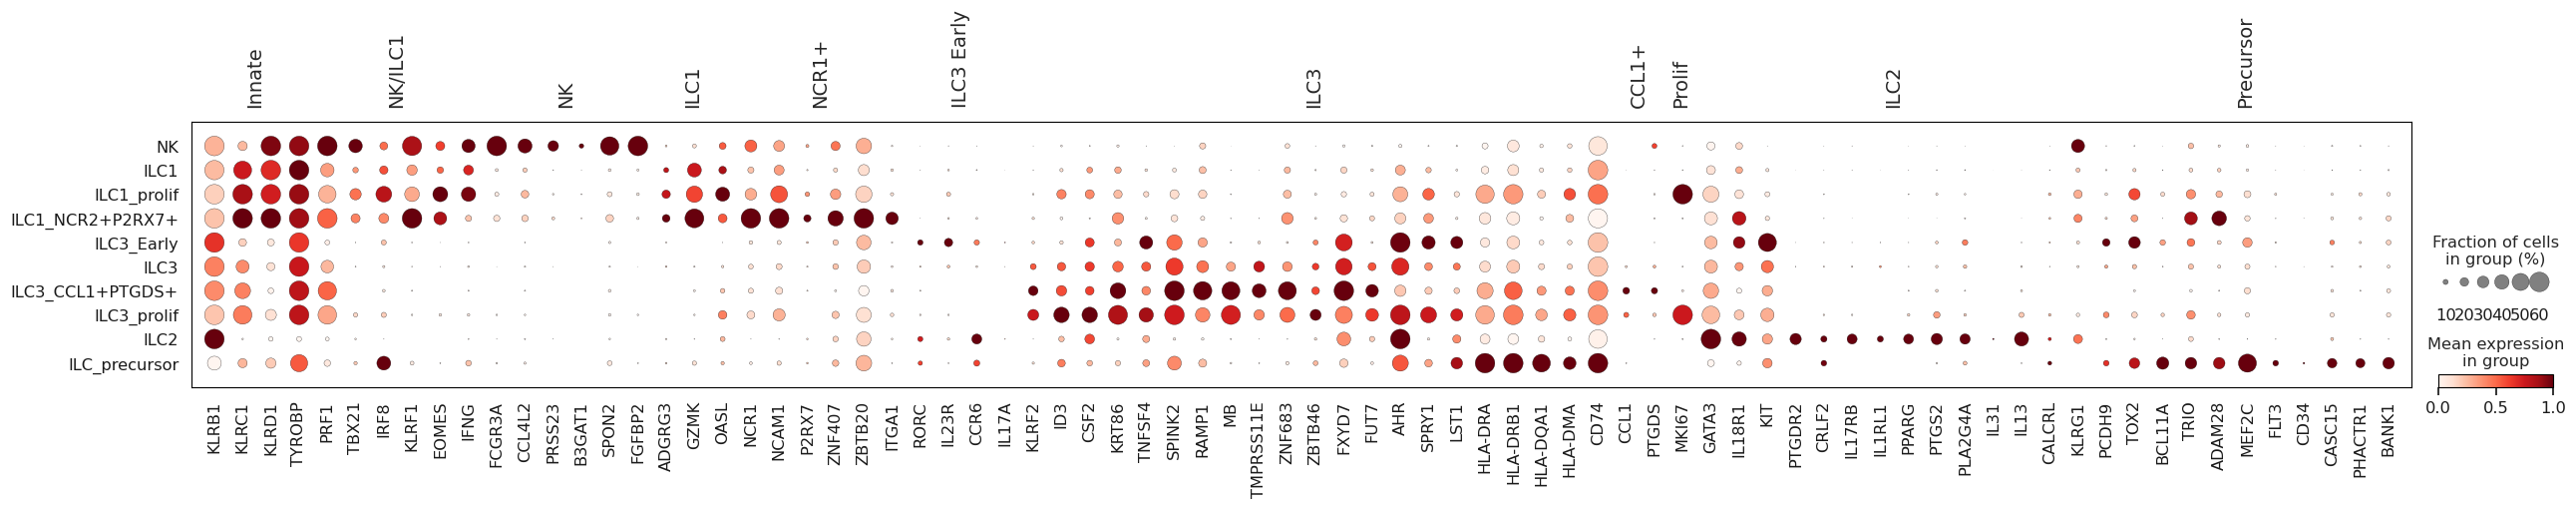

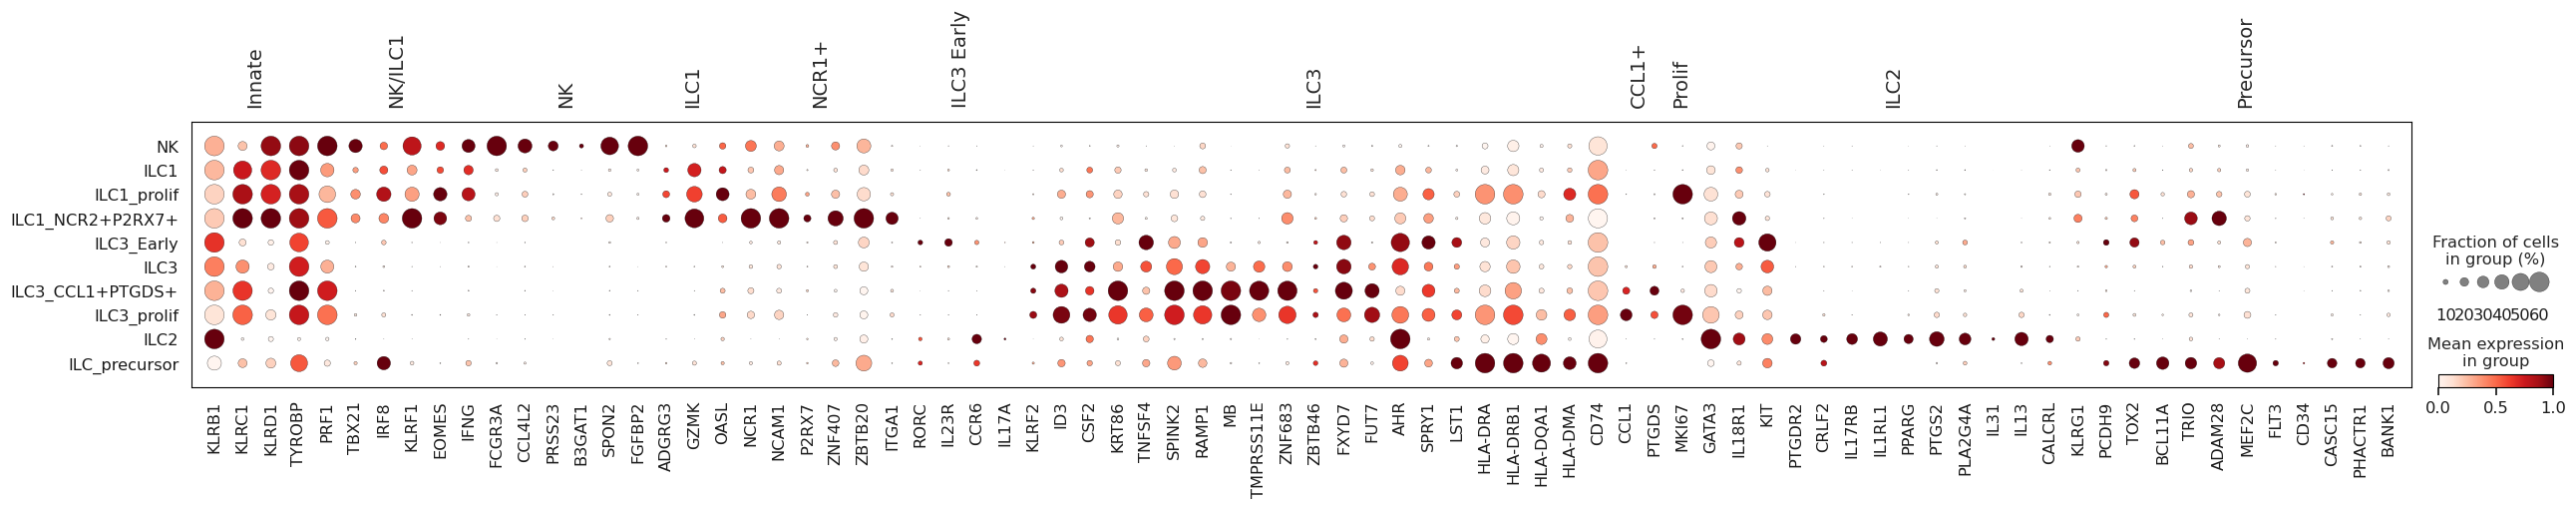

In [69]:
sc.pl.dotplot(
    adata_ilc[~adata_ilc.obs["Patient_status"].isin(["Eczema", "Psoriasis"])],
    remove_markers(ALLT2, adata_ilc),
    groupby="lvl4_annotation2",
    dendrogram=False,
    vmax=1,
    dot_max=0.6,
   standard_scale="var",
    
   categories_order=['NK', 'ILC1','ILC1_prolif', 'ILC1_NCR2+P2RX7+',      
                      
                  #   'ILC3_TOX2+_earliest',
                  'ILC3_Early',
                   'ILC3', 'ILC3_CCL1+PTGDS+', 
                     
                    #  'ILC3_prolif', 
                                           'ILC3_prolif', 

                       'ILC2',
                      'ILC_precursor',
                   
               
                    ],
 save=f"ilc_allatlas_NO_ad_pso2.pdf"

) 

sc.pl.dotplot(
    adata_ilc,#[~adata_ilc.obs["Patient_status"].isin(["Eczema", "Psoriasis"])],
    remove_markers(ALLT2, adata_ilc),
    groupby="lvl4_annotation2",
    dendrogram=False,
    vmax=1,
    dot_max=0.6,
   standard_scale="var",
    
   categories_order=['NK', 'ILC1','ILC1_prolif', 'ILC1_NCR2+P2RX7+',      
                      
                  #   'ILC3_TOX2+_earliest',
                  'ILC3_Early',
                   'ILC3', 'ILC3_CCL1+PTGDS+', 
                     
                    #  'ILC3_prolif', 
                                           'ILC3_prolif', 

                       'ILC2',
                      'ILC_precursor',
                   
               
                    ],
 save=f"ilc_allatlas2.pdf"

) 




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

props = pd.crosstab(adata_ilc.obs["Patient_status"], adata_ilc.obs["lvl4_annotation"], normalize="index") * 100

cols = [c for c in props.columns if c in colors]
props = props[cols]
col_colors = [colors[c] for c in cols]

# Sort by ILC2 proportion high to low
if "ILC2" in props.columns:
    props = props.sort_values("ILC2", ascending=False)

props.plot.bar(stacked=True, color=col_colors, figsize=(12, 6))
plt.ylabel("% cells")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

props = pd.crosstab(adata_ilc.obs["Patient_status"], adata_ilc.obs["lvl4_annotation"], normalize="index") * 100

cols = [c for c in props.columns if c in colors]
props = props[cols]
col_colors = [colors[c] for c in cols]

# Sort by ILC2 proportion high to low
if "ILC3_CCL1+PTGDS+" in props.columns:
    props = props.sort_values("ILC3_CCL1+PTGDS+", ascending=False)

props.plot.bar(stacked=True, color=col_colors, figsize=(12, 6))
plt.ylabel("% cells")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

props = pd.crosstab(adata_ilc.obs["Patient_status"], adata_ilc.obs["lvl4_annotation"], normalize="index") * 100

cols = [c for c in props.columns if c in colors]
props = props[cols]
col_colors = [colors[c] for c in cols]

# Sort by ILC2 proportion high to low
if "ILC3" in props.columns:
    props = props.sort_values("ILC3", ascending=False)

props.plot.bar(stacked=True, color=col_colors, figsize=(12, 6))
plt.ylabel("% cells")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# props = pd.crosstab(adata_ilc.obs["Patient_status"], adata_ilc.obs["lvl4_annotation"], normalize="index") * 100

# # Keep ALL columns, assign grey to missing colors
# col_colors = [colors.get(c, "grey") for c in props.columns]

# # Sort by ILC2 proportion (high to low)
# if "ILC2" in props.columns:
#     props = props.sort_values("ILC2", ascending=False)

# props.plot.bar(stacked=True, color=col_colors, figsize=(12, 6))
# plt.ylabel("% cells")
# plt.xlabel("")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [ ]:
adata_ilc.shape

In [ ]:
33

In [ ]:
a

In [ ]:
# CATEGORY="lvl4_annotation"
# sc.tl.rank_genes_groups(adata_ilc, CATEGORY, method='wilcoxon', key_added="de_leiden");
# df22 = pd.DataFrame(adata_ilc.uns['de_leiden']['names'])
# for i,x in enumerate(df22.columns):
#     print(i, x)



In [ ]:

# select_population = list(df22.columns)[-2
                                       
                                       
#                                       ]  # JAW
# print(select_population)
# genes0 = df22[select_population][:50]
# genes1 = df22[select_population][50:100]
# genes2 = df22[select_population][100:150]
# genes3 = df22[select_population][150:200]
# genes4 = df22[select_population][200:250]
# genes5 = df22[select_population][250:300]
# genes6 = df22[select_population][300:350]


# sc.pl.dotplot(
#     adata_ilc,
#     genes0,
#     groupby=CATEGORY,
#   #  standard_scale="var",
#     dendrogram=False, 
# )
# sc.pl.dotplot(
#     adata_ilc,
#     genes1,
#     groupby=CATEGORY,
#    #standard_scale="var",
#     dendrogram=False, 
# ) 
# sc.pl.dotplot(
#     adata_ilc,
#     genes2,
#     groupby=CATEGORY,
#    #standard_scale="var",
#     dendrogram=False, 
# ) 

# #s tress dusp5,DNAJA1, JUND, 



In [ ]:
# sc.pl.dotplot(
#     adata_ilc,
#     genes3,
#     groupby=CATEGORY,
#   #  standard_scale="var",
#     dendrogram=False, 
# )
# sc.pl.dotplot(
#     adata_ilc,
#     genes4,
#     groupby=CATEGORY,
#    #standard_scale="var",
#     dendrogram=False, 
# ) 
# sc.pl.dotplot(
#     adata_ilc,
#     genes5,
#     groupby=CATEGORY,
#    #standard_scale="var",
#     dendrogram=False, 
# ) 


In [ ]:
adata[adata.obs["lvl4_annotation"]=="ILC_SELL+CCR7+"].obs.Patient_status.value_counts()

In [ ]:
sc.pl.dotplot(
    adata,
    ["IL23A", "IL23R"],
    groupby="lvl4_annotation",
    dendrogram=False,
    vmax=1,
   # standard_scale="var",
    
#    categories_order=['NK', 'ILC1','ILC1_prolif', 'ILC1_NCR2+P2RX7+',
                  
#                    'ILC3', 'ILC3 CCL1+PTGDS+', 
#                       'ILC3_prolif', 
#                        'ILC2',
#                     ],
 # save=f"ilc_allatlas.pdf"

) 


# ilc

In [ ]:
adata_iiii=adata_iii[ (adata_iii.obs["lvl4_annotation"].str.startswith("ILC3"))
                    ]
adata_iiii=adata_iiii[adata_iiii.obs["lvl4_annotation"]!="ILC3_prolif"]
adata_iiii.obs["lvl4_annotation"].value_counts()


In [ ]:
# sc.pp.normalize_total(adata_iiii, target_sum=1e4)
# sc.pp.log1p(adata_iiii)


In [ ]:
# Step 1: Count the number of cells per Patient_status
counts = adata_iiii[adata_iiii.obs["lvl4_annotation"]=="ILC3 CCL1+PTGDS+"].obs["Patient_status"].value_counts()

# Step 2: Identify Patient_status values with at least 20 cells
valid_statuses = counts[counts >= 5].index

# Step 3: Filter the AnnData object
adata_iiii = adata_iiii[adata_iiii.obs["Patient_status"].isin(valid_statuses)].copy()
adata_iiii.obs["Patient_status"].value_counts()
# Step 1: Count cells per group
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Build new labels like "PatientA (n=123)"
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}

# Step 3: Add a new column with updated labels
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs["Patient_status"].map(label_map)

# Step 4: Sort by counts descending
sorted_labels = [label_map[g] for g in counts.index]


In [ ]:
ILC1_CCL1_GENES = {"ILC3":   ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
    
                    "Polarised": ["MB" ,"KRT86", "NEDD8", "EVL" , "KRT81", "ZNF683", "SIRPG", "PYCARD",
                  "MVP", "SDHC", "KRT14", "NME1", "NCR3", 
                   "CST6",
                  
                  ]}
# # Step 5: Plot
# sc.pl.dotplot(
#     adata_iiii,
#     ILC1_CCL1_GENES,
#     groupby="Patient_status_ILC3",
#     dendrogram=False,
#     standard_scale="var",
#     #categories_order=sorted_labels,
#    # dot_max=.6
# )

In [ ]:
# adata_i=adata[adata.obs["lvl4_annotation"]=="ILC3_CCL1+PTGDS+"]


In [ ]:
ALLT2 = {'Innate': [
  'KLRB1',
  'KLRC1',
  'TYROBP',
  'FCER1G',
],

          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
           'PTGDS': [  'PTGDS', 'PDLIM4', 'CCL1'],


 'ILC2+3': ['IL9R', 'TNFSF11'],
 'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',
  'PPARG',
  'PTGS2',
  'PLA2G4A',

  'NRROS',     'IL31',
'IL22', 'IL13', 
         ],
 # 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],
 # 'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
 #        "RORC+": ["RORC",]
        }

             
adata_iiii=adata_iii[ (adata_iii.obs["lvl4_annotation"].str.startswith("ILC3 CCL"))|
                     (adata_iii.obs["lvl4_annotation"].str.startswith("ILC3_CCL"))
                    ]
adata_iiii.obs["lvl4_annotation"].value_counts()
# sc.pp.normalize_total(adata_iiii, target_sum=1e4)
# sc.pp.log1p(adata_iiii)

# Step 1: Count the number of cells per Patient_status
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Identify Patient_status values with at least 20 cells
valid_statuses = counts[counts >= 5].index

# Step 3: Filter the AnnData object
adata_iiii = adata_iiii[adata_iiii.obs["Patient_status"].isin(valid_statuses)].copy()
adata_iiii.obs["Patient_status"].value_counts()
# Step 1: Count cells per group
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Build new labels like "PatientA (n=123)"
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}

# Step 3: Add a new column with updated labels
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs["Patient_status"].map(label_map)

# Step 4: Sort by counts descending
sorted_labels = [label_map[g] for g in counts.index]



In [ ]:
sorted(adata_iiii.obs["Patient_status_labeled"].unique())

In [ ]:
adata_iiii=adata_iiii[adata_iiii.obs["Patient_status_labeled"]!='Psoriasis (n=32)']

In [ ]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(8,8))

sc.pl.DotPlot(
    adata_iiii,
   remove_markers(ALLT2),
    #swap_axes=True,
    groupby="Patient_status_labeled",
   vmax=1.5,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
    categories_order=['Bullous pemphigoid (n=19)',
 'Eczema (n=356)',
                       'Prurigo nodularis (n=11)',
# 'Psoriasis (n=32)',
 'Lyme_disease/Erythema migrans (n=9)',

 'Vitiligo (n=5)']
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=1

          )\
.show()

sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))



In [ ]:
sc.pl.DotPlot(
    adata_iiii,
   remove_markers(ILC1_CCL1_GENES),
    #swap_axes=True,
    groupby="Patient_status_labeled",
   vmax=1.5,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
    categories_order=['Bullous pemphigoid (n=19)',
 'Eczema (n=356)',
                       'Prurigo nodularis (n=11)',
# 'Psoriasis (n=32)',
 'Lyme_disease/Erythema migrans (n=9)',

 'Vitiligo (n=5)']
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=1

          )\
.show()

In [ ]:
stop

# Show all atlas

In [ ]:
import scanpy as sc


In [ ]:
adata=sc.read_h5ad('/nfs/team298/ls34/gold_adatas/adultskin/adata_skin_with_junk_forTcells.h5ad')
adata.shape


In [ ]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

G_C = {
    "Other": "#E5E5E5",
    "T/ILC": "#FFD700"
}
sc.pl.umap(
    adata,
    color=[
   't_vs_other',
    ],
   # legend_loc="on data",
    s=1, 
    legend_fontoutline=2,
    legend_fontsize=8,
    palette=G_C,
    save="TILC_vs_other.pdf",
    title=""
)


 

# subcluster ilc2§m

In [ ]:
adata_i=adata[adata.obs["lvl4_annotation"].str.startswith("ILC2")].copy()
sc.pp.neighbors(adata_i, use_rep = 'X_scvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 
sc.pl.umap(
    adata_i,
    color=[
        'lvl4_annotation'  
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=['IL17RB', 'KLRG1', 'IL10RA', 'PDCD1', 'MAF'  , "CTLA4"  ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    vmax="p99",
    ncols=3,
    cmap="Reds",
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=['BACH2', 'SATB1', 'IRF4', 'ZEB2',  ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    vmax="p99",
    ncols=3,
    cmap="Reds",
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'KLRG1', "CCR7", "FLT3","IL26"  , "IL13", "ICOS", #"PPARG",
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    vmax=1,
    ncols=3,
    cmap="Reds",
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'RORC', "IL17A"  
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    vmax=1,
    cmap="Reds",
)

In [ ]:
sc.tl.leiden(adata_i, resolution=0.2, key_added='leiden_res0.2', neighbors_key="neighbor_20")


In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'leiden_res0.2',  
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    vmax=1,
    cmap="Reds",
)

In [ ]:
CATEGORY="leiden_res0.2"
sc.tl.rank_genes_groups(adata_i, CATEGORY, method='wilcoxon', key_added="de_leiden");
df22 = pd.DataFrame(adata_i.uns['de_leiden']['names'])
for i,x in enumerate(df22.columns):
    print(i, x)

In [ ]:
select_population = list(df22.columns)[2
                                       
                                       
                                      ]  # JAW
print(select_population)
genes0 = df22[select_population][:50]
genes1 = df22[select_population][50:100]
genes2 = df22[select_population][100:150]
genes3 = df22[select_population][150:200]
genes4 = df22[select_population][200:250]
genes5 = df22[select_population][250:300]
genes6 = df22[select_population][300:350]


sc.pl.dotplot(
    adata_i,
    genes0,
    groupby=CATEGORY,
  #  standard_scale="var",
    dendrogram=False, 
)
sc.pl.dotplot(
    adata_i,
    genes1,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 
sc.pl.dotplot(
    adata_i,
    genes2,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 

#s tress dusp5,DNAJA1, JUND, 



In [ ]:
RENAME = {'0': ["CHD2", "ELL2", "PBX4"],
          '1': ["IL26", "IL13", "LGALS3", "ALOX5AP", "RFLNB",],
          '2': ['PLAC8', "GIMAP1",],
         "OTHER": ["RORC", "IL17A"]
         }
sc.pl.dotplot(
    adata_i,
    RENAME,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 

#s tress dusp5,DNAJA1, JUND, 




In [ ]:
adata_i[adata_i.obs["leiden_res0.2"]=="1"].obs.Patient_status.value_counts()

In [ ]:
{x:x for x in sorted(adata_i.obs["leiden_res0.2"].unique())}

In [ ]:
RENAME = {'0': 'ILC2', '1': 'ILC2_IL26+', '2': 'ILC2_PLAC8+'}
adata_i.obs["leiden_res0.2"]=adata_i.obs["leiden_res0.2"].map(RENAME)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'leiden_res0.2',  
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=30,
    vmax=1,
    cmap="Reds",
)

In [ ]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2_ilc2only.h5ad'
adata_i.write(PATH)


# ilc2 + 3

In [ ]:
adata_i=adata[(adata.obs["lvl4_annotation"].str.startswith("ILC3"))|
             (adata.obs["lvl4_annotation"].str.startswith("ILC_S"))|
               (adata.obs["lvl4_annotation"].str.startswith("ILC1"))|
               (adata.obs["lvl4_annotation"].str.startswith("ILC2"))
             ].copy()
sc.pp.neighbors(adata_i, use_rep = 'X_scvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 
sc.pl.umap(
    adata_i,
    color=[
        'RORC', "IL17A"  
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        "lvl4_annotation" 
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'PDCD1', "CTLA4"  , 
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'FLT3', "CD34"  , "BCL11A", "TCF3", "RORC", "ZBTB16", "IL7R", "FCGR3A"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

# ILC 3 AND EARLY

In [ ]:
adata_i=adata[(adata.obs["lvl4_annotation"].str.startswith("ILC3"))|
             (adata.obs["lvl4_annotation"].str.startswith("ILC_S"))
             ].copy()
sc.pp.neighbors(adata_i, use_rep = 'X_scvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 
sc.pl.umap(
    adata_i,
    color=[
        'lvl4_annotation', #"IL17A"  
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'CIITA', "HLA-DRA"  , "HLA-DRB1", 
        
        #TCF3", "RORC", "ZBTB16", "IL7R", "FCGR3A"
    ],
    legend_loc="on data",
    ncols=3,
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=2,
    #save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'FLT3', "CD34"  , "BCL11A", 
        'RORC','NR6A1', 'MS4A1'
        
        #TCF3", "RORC", "ZBTB16", "IL7R", "FCGR3A"
    ],
    legend_loc="on data",
    ncols=3,
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    #save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'FLT3', "CD34"  , "BCL11A", "TCF3", "RORC", "ZBTB16", "IL7R"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
genes2=["RORC", "TOX2",   "ZBTB46", "IL17A","IL23R", "CXCR5", "GPR183"]
        
sc.pl.umap(
    adata_i,
    color=genes2,
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=5,
    #save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color="Site_status_binary",
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
genes2=["NFIL3", "NOTCH1",   "NOTCH2"]
        
sc.pl.umap(
    adata_i,
    color=genes2,
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
genes2=["TCF7", "TOX", "IKZF2", "RUNX3", "MAF", 'BCL2', "CD7", "ID2", "ETS1", "RORA", "AHR", "CXCR6", "GATA3"]
        
sc.pl.umap(
    adata_i,
    color=genes2,
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=["KLRK1", "CXCR5", "CCR6", "ITGA4", "CD82"],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
GENES = ['MEF2C', 'IGHM', 
        'TCF4', 'HLA-DRB5', 
        'CCSER1', 'BANK1', 
        'MS4A1', 'CD79A', 'CASC15',  'PHACTR1', 'ADAM28', 'TOX2', 'TRIO', 'GRK3', 'IFI30','IL3RA', 'NR6A1', 
        ]
    

In [ ]:
sc.pl.umap(
    adata_i,
    color=GENES,
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=["CCR7", "LTB", "LTA", "STAT3"],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    #save="ilc3_only_umap.pdf"
)

# ILC3

In [ ]:
adata_i=adata[adata.obs["lvl4_annotation"].str.startswith("ILC3")].copy()
sc.pp.neighbors(adata_i, use_rep = 'X_scvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 
sc.pl.umap(
    adata_i,
    color=[
        'lvl4_annotation', 
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
adata_i[adata_i.obs["Site_status_binary"].isna()].obs.Mapping_status.value_counts()

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'Site_status_binary',
    ],
   # legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'ZBTB46', "TNFSF4" , "HBEGF"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'RORC', "IL17A"  , "TOX2" 
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'CCR6', "CCR8"  ,
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    save="ilc3_only_umap_CCR4_CCR6.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'XCR1', "IRF8"  , "IRF4" , "SIRPA"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    #save="ilc3_only_umap_ZBTB46.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'CCR7', "TOX2" , "BCL11A" , "FLT3", "TCF3", 
    ],
    legend_loc="on data",
    s=200, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    ncols=6,
    save="ilc3_only_umap_IL22.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'RORC', "IL22" , "IL23R" , "TOX2", "CCR6", "CCR8",   
    ],
    legend_loc="on data",
    s=200, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    ncols=6,
    save="ilc3_only_umap_IL22.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'RORC', "IL17A" , "IL23R" , "TOX2", "CCR6", "CCR8",   
    ],
    legend_loc="on data",
    s=200, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    ncols=6,
    save="ilc3_only_umap_IL17A.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'RORC', "ZBTB46"  , "TOX2", "CCR6", "CCR8", "IL23R"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=1,
    ncols=6,
    save="ilc3_only_umap_.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
     "IL22", 'LTA', 'NRP1', 'IL1R1', "TOX2", "BATF", "BATF3"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
     "ZBTB16", 'PDCD1', 'BCL11B', 'BCL11A', "TCF7", "IL2RA"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
     "TAL1", 'ITGA4', "ITGB7", "RORC", "TOX2"  ,"ZBTB16"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
     "TAL1", 'ITGA4', "RORC", "TOX2"  ,
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:

sc.pl.umap(
    adata_i,
    color=[
   'RORC', #'IL4I1',
         'TOX2', 'LST1',
        'CCR7', "IL23R","ITGA4"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    ncols=3,
    save="ilc3_only_umap.pdf"
)

In [ ]:

sc.pl.umap(
    adata_i,
    color=[
   'RORC', #'IL4I1',
         'TOX2', 'LST1',
        'CCR7', "IL23R","ITGA4"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
    ncols=3,
    save="ilc3_only_umap.pdf"
)

In [ ]:

sc.pl.umap(
    adata_i,
    color=[
    'TOX2', 'RORC', 'IL4I1', 'LST1','CCR7', "IL23R"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
     "ID2", 'ID3', 'TCF7', 'HHEX', 'LMO2', "NFIL3", "IL7R", "CD4"
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax="p99",
   # save="ilc3_only_umap.pdf"
)

In [ ]:
sc.tl.leiden(adata_i, resolution=0.5, key_added='leiden_res0.5', neighbors_key="neighbor_20")


In [ ]:
sc.tl.leiden(adata_i, resolution=0.3, key_added="t2", neighbors_key= "neighbor_20",
      restrict_to=("leiden_res0.5",["2"]), 
            )
sc.pl.umap(
    adata_i,
    color=[
        't2'
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
adata_i[adata_i.obs["provisional2"]=='ILC3_TOX2+_earliest'].obs.Patient_status.value_counts()

In [ ]:
RENAME = {'0': 'ILC3',
 '1': 'ILC3',
 '2,0': 'ILC3_TOX2+_earliest',
 '2,1': 'ILC3_Early',
 '2,2': 'ILC3_TOX2+_earliest',
 '2,3': 'ILC3_Early' ,
 '3': 'ILC3',
 '4': 'ILC3_CCL1+PTGDS+',
 '5': 'ILC3_Prolif'}
adata_i.obs["provisional2"]=adata_i.obs["t2"].map(RENAME)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'provisional2' 
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,cmap="Reds",
    vmax=2,
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'leiden_res0.5'
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
sc.pl.umap(
    adata_i,
    color=[
        'lvl4_annotation'
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
CATEGORY="t2"
sc.tl.rank_genes_groups(adata_i, CATEGORY, method='wilcoxon', key_added="de_leiden");
df22 = pd.DataFrame(adata_i.uns['de_leiden']['names'])
for i,x in enumerate(df22.columns):
    print(i, x)

In [ ]:
select_population = list(df22.columns)[2
                                       
                                       
                                      ]  # JAW
print(select_population)
genes0 = df22[select_population][:50]
genes1 = df22[select_population][50:100]
genes2 = df22[select_population][100:150]
genes3 = df22[select_population][150:200]
genes4 = df22[select_population][200:250]
genes5 = df22[select_population][250:300]
genes6 = df22[select_population][300:350]


sc.pl.dotplot(
    adata_i,
    genes0,
    groupby=CATEGORY,
  #  standard_scale="var",
    dendrogram=False, 
)
sc.pl.dotplot(
    adata_i,
    genes1,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 
sc.pl.dotplot(
    adata_i,
    genes2,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 

#s tress dusp5,DNAJA1, JUND, 



In [ ]:
MARKERS = {'0': ["CHD2", "ELL2", "PBX4"],
          '1': ["IL26", "IL13", "LGALS3", "ALOX5AP", "RFLNB",],
          '2': ['PLAC8', "GIMAP1",],
         "OTHER": ["RORC", "IL17A"],
           "2.0": ['TOX2', 'RORC', 'IL4I1', 'LST1','CCR7', "IL23R"]
         }
sc.pl.dotplot(
    adata_i,
    MARKERS,
    groupby="t2",
   #standard_scale="var",
    dendrogram=False, 
) 

#s tress dusp5,DNAJA1, JUND, 


sc.pl.dotplot(
    adata_i,
    MARKERS,
    groupby="leiden_res0.5",
   #standard_scale="var",
    dendrogram=False, 
) 

#s tress dusp5,DNAJA1, JUND, 

sc.pl.dotplot(
    adata_i,
    MARKERS,
    groupby="provisional2",
   #standard_scale="var",
    dendrogram=False, 
) 


In [ ]:
sc.pl.dotplot(
    adata_i,
    genes3,
    groupby=CATEGORY,
  #  standard_scale="var",
    dendrogram=False, 
)
sc.pl.dotplot(
    adata_i,
    genes4,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 
sc.pl.dotplot(
    adata_i,
    genes5,
    groupby=CATEGORY,
   #standard_scale="var",
    dendrogram=False, 
) 

#s tress dusp5,DNAJA1, JUND, 



In [ ]:
{x:x for x in sorted(adata_i.obs["t2"].unique())}

In [ ]:
{x:x for x in

In [ ]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2_ilc3only.h5ad'
adata_i.write(PATH)


In [ ]:
import scanpy as sc
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2_ilc3only.h5ad'
adata_i=sc.read_h5ad(PATH)


In [ ]:
adata